# imports

In [ ]:
!pip install qiskit-ibm-runtime
!pip install qiskit-aer

In [ ]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt, patches
import cmath, math
import random
import sys
import time
random.seed(42)

In [ ]:
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import MCXGate, UnitaryGate, QFT

In [ ]:
def viz2(state_vector, num_of_qubit = 3):
  n_states = int(math.pow(2,num_of_qubit))

  # calculate the amplitude and phase of the states
  prob_qubit = np.absolute(state_vector)
  phase_qubit = np.angle(state_vector)
  rows = int(math.ceil(n_states / 8.0))
  cols = min(n_states, 8)
  fig, axs = plt.subplots(rows, cols)
  for col in range(cols):
    # amplitude area
    circleExt = matplotlib.patches.Circle((0.5, 0.5), 0.5, color='gray',alpha=0.1)
    circleInt = matplotlib.patches.Circle((0.5, 0.5), prob_qubit[col]/2, color='b',alpha=0.3)
    axs[col].add_patch(circleExt)
    axs[col].add_patch(circleInt)
    axs[col].set_aspect('equal')
    state_number = "|" + str(col) + ">"
    axs[col].set_title(state_number)
    xl = [0.5, 0.5 + 0.5*prob_qubit[col]*math.cos(phase_qubit[col] + np.pi/2)]
    yl = [0.5, 0.5 + 0.5*prob_qubit[col]*math.sin(phase_qubit[col] + np.pi/2)]
    axs[col].plot(xl,yl,'r')
    axs[col].axis('off')
  plt.show()

def vizMulti(state_vector, num_of_qubit = 3):
  n_states = int(math.pow(2,num_of_qubit))

  # calculate the amplitude and phase of the states
  prob_qubit = np.absolute(state_vector)
  phase_qubit = np.angle(state_vector)
  rows = int(math.ceil(n_states / 16.0))
  cols = min(n_states, 16)

  # Create the subplots
  fig, axs = plt.subplots(rows, cols)

  # Flatten axs in case it is a 2D array
  axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]

  for col in range(n_states):  # loop over all possible states
    # amplitude area
    circleExt = matplotlib.patches.Circle((0.5, 0.5), 0.5, color='gray', alpha=0.1)
    circleInt = matplotlib.patches.Circle((0.5, 0.5), prob_qubit[col] / 2, color='b', alpha=0.3)
    axs[col].add_patch(circleExt)
    axs[col].add_patch(circleInt)
    axs[col].set_aspect('equal')
    state_number = "|" + str(col) + ">"
    axs[col].set_title(state_number, fontsize=5)
    xl = [0.5, 0.5 + 0.5 * prob_qubit[col] * math.cos(phase_qubit[col] + np.pi / 2)]
    yl = [0.5, 0.5 + 0.5 * prob_qubit[col] * math.sin(phase_qubit[col] + np.pi / 2)]
    axs[col].plot(xl, yl, 'r')
    axs[col].axis('off')

  plt.show()

# Encapsulation

In [ ]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import math
import random
random.seed(42)


class PolarQuantumCircuit:
    def __init__(self, num_qubits: int, initial_state=None):
        self._num_qubits = num_qubits
        self._state_size = 2**num_qubits

        if initial_state is None:
            self._state = [(1.0 if i == 0 else 0.0, 0.0)
                           for i in range(self._state_size)]
        else:
            if len(initial_state) != self._state_size:
                raise ValueError(
                    "initial_state size does not match nun_qubits!")
            self._state = initial_state

        self._applied_gates = []

    def get_circuit_info(self):
        """
        Returns information about the quantum circuit, including the number of qubits
        and the gates applied so far.
        """
        return {"num_qubits": self._num_qubits, "gates_applied": self._applied_gates}

    def reset(self):
        """
        Resets the quantum circuit to the |0> state.
        """
        self._state = [(1.0 if i == 0 else 0.0, 0.0)
                       for i in range(self._state_size)]

    def get_state(self):
        """
        Returns the current state of the quantum circuit.
        """
        return self._state.copy()

    def _validate_qubit_index(self, qubit):
        if not (0 <= qubit < self._num_qubits):
            raise ValueError(
                f"Qubit {qubit} is out of bounds for this {self._num_qubits}-qubit circuit!")

    def _round_state(self):
        """
        Rounds small numerical values in the state to improve numerical stability.
        """
        threshold = 1e-6

        for i in range(len(self._state)):
            r, theta = self._state[i]
            if abs(r) < threshold:
                r = 0.0
            if abs(r - 1.0) < threshold:
                r = 1.0
            if theta < -np.pi:
                if abs(theta - (-np.pi)) > threshold:
                    theta += 2 * np.pi
                else:
                    theta = -np.pi
            if theta >= np.pi:
                if abs(theta - np.pi) > threshold:
                    theta -= 2 * np.pi
                else:
                    theta = -np.pi
            self._state[i] = (r, theta)

    @staticmethod
    def polar2cartesian(polar_states):
        """
        Translate the polar coordinate (r, theta) into Cartesian coordinate (a + bi).
        """
        cartesian_states = [
            complex(r * math.cos(theta), r * math.sin(theta)) for r, theta in polar_states]
        return cartesian_states

    @staticmethod
    def cartesian2polar(cartesian_states):
        """
        Translate the Cartesian coordinate (a + bi) into polar coordinate (r, theta) .
        """
        polar_states = []
        for complexelement in cartesian_states:
            r = math.sqrt(complexelement.real**2 + complexelement.imag**2)
            theta = math.atan2(complexelement.imag, complexelement.real)
            if abs(theta - math.pi) < 1e-6:
                theta = -math.pi
            polar_states.append((r, theta))

        return polar_states

    def NOT_polar(self, target_qubit):
        """
        Apply the NOT gate to the target_qubit.
        """
        self._validate_qubit_index(target_qubit)
        self._applied_gates.append({"gate": "NOT", "target": target_qubit})

        new_state = self._state.copy()

        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            if (i >> target_qubit) & 1 == 0:
                index_0 = i
                index_1 = i | (1 << target_qubit)
            else:
                index_0 = i & ~(1 << target_qubit)
                index_1 = i

            # Update the new state
            new_state[index_0] = self._state[index_1]
            new_state[index_1] = self._state[index_0]

        self._state = new_state.copy()
        self._round_state()

    def CNOT_polar(self, control_qubit, target_qubit, log=True):
        """
        Apply the CNOT gate to the target_qubit only if the control_qubit is 1.
        """
        self._validate_qubit_index(target_qubit)
        if log:
            self._applied_gates.append(
                {"gate": "CNOT", "control": control_qubit, "target": target_qubit})

        new_state = self._state.copy()

        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            if (i >> control_qubit) & 1 != 0:
                if (i >> target_qubit) & 1 == 0:
                    index_0 = i
                    index_1 = i | (1 << target_qubit)
                else:
                    index_0 = i & ~(1 << target_qubit)
                    index_1 = i

                # Update the new state
                new_state[index_0] = self._state[index_1]
                new_state[index_1] = self._state[index_0]

        self._state = new_state.copy()
        self._round_state()

    def MCX_polar(self, control_qubits, target_qubit):
        """
        Apply the MCX gate to the target_qubit only if control_qubits are 1s.
        """
        for i in control_qubits:
            self._validate_qubit_index(i)
        self._validate_qubit_index(target_qubit)
        self._applied_gates.append(
            {"gate": "MCX", "control": control_qubits, "target": target_qubit})

        new_state = self._state.copy()

        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            flag = True
            for j in control_qubits:
                if (i >> j) & 1 == 0:
                    flag = False
            if flag:
                if (i >> target_qubit) & 1 == 0:
                    index_0 = i
                    index_1 = i | (1 << target_qubit)
                else:
                    index_0 = i & ~(1 << target_qubit)
                    index_1 = i

                # Update the new state
                new_state[index_0] = self._state[index_1]
                new_state[index_1] = self._state[index_0]

        self._state = new_state.copy()
        self._round_state()

    def hadamard_polar(self, target_qubit):
        """
        Apply the hadamard gate to the target_qubit.
        """
        self._validate_qubit_index(target_qubit)
        self._applied_gates.append(
            {"gate": "HADAMARD", "target": target_qubit})

        new_state = self._state.copy()

        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            if (i >> target_qubit) & 1 == 0:
                index_0 = i
                index_1 = i | (1 << target_qubit)
            else:
                index_0 = i & ~(1 << target_qubit)
                index_1 = i

            # Get the polar components for |0> and |1> of the target qubit
            r0, theta0 = self._state[index_0]
            r1, theta1 = self._state[index_1]

            # calculate by the rotating property of complex number
            delta_theta = theta1 - theta0
            r_new_0 = np.sqrt(
                0.5 * ((r0 + r1 * np.cos(delta_theta)) ** 2 + (r1 * np.sin(delta_theta)) ** 2))
            theta_new_0 = theta0 + \
                np.arctan2(r1 * np.sin(delta_theta),
                           r0 + r1 * np.cos(delta_theta))

            r_new_1 = np.sqrt(
                0.5 * ((r0 - r1 * np.cos(delta_theta)) ** 2 + (r1 * np.sin(delta_theta)) ** 2))
            theta_new_1 = theta0 + \
                np.arctan2(- r1 * np.sin(delta_theta),
                           r0 - r1 * np.cos(delta_theta))

            # Update the new state
            new_state[index_0] = [r_new_0, theta_new_0]
            new_state[index_1] = [r_new_1, theta_new_1]

        self._state = new_state.copy()
        self._round_state()

    def PHASE_polar(self, target_qubit, phi):
        """
        Apply the PHASE gate to the 'target_qubit' with a phase change 'phi'.

            keep the theta in _state: in the range [-pi, pi]
        """
        self._validate_qubit_index(target_qubit)
        self._applied_gates.append(
            {"gate": "PHASE", "target": target_qubit, "phi": phi})

        new_state = self._state.copy()

        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            if (i >> target_qubit) & 1 != 0:
                new_theta = self._state[i][1] + phi
                if new_theta < -np.pi and abs(new_theta+np.pi) > 1e-6:
                    new_theta += np.pi * 2
                if new_theta > np.pi and abs(new_theta-np.pi) > 1e-6:
                    new_theta -= np.pi * 2
                new_state[i] = (self._state[i][0], new_theta)

        self._state = new_state.copy()
        self._round_state()

    def CPHASE_polar(self, control_qubit, target_qubit, phi):
        """
        Apply the CPHASE gate to the 'target_qubit' with a phase change 'phi' only if the 'control_qubit' is 1.

            keep the theta in _state: in the range [-pi, pi]
        """
        self._validate_qubit_index(target_qubit)
        self._applied_gates.append(
            {"gate": "CPHASE", "control": control_qubit, "target": target_qubit, "phi": phi})

        new_state = self._state.copy()

        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            if (i >> control_qubit) & 1 == 1:
                if (i >> target_qubit) & 1 == 1:
                    new_theta = self._state[i][1] + phi
                    new_state[i] = (self._state[i][0], new_theta)

        self._state = new_state.copy()
        self._round_state()

    def CCPHASE_polar(self, control_qubits, target_qubit, phi):
        """
        Apply the CCPHASE gate to the 'target_qubit' with a phase change 'phi' only if the 'control_qubits' are 1s.

            keep the theta in _state: in the range [-pi, pi]
        """
        for i in control_qubits:
            self._validate_qubit_index(i)
        self._validate_qubit_index(target_qubit)
        self._applied_gates.append(
            {"gate": "CCPHASE", "control": control_qubits, "target": target_qubit, "phi": phi})

        new_state = self._state.copy()

        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            flag = True
            for j in control_qubits:
                if (i >> j) & 1 == 0:
                    flag = False
            if flag:
                if (i >> target_qubit) & 1 == 1:
                    new_theta = self._state[i][1] + phi
                    new_state[i] = (self._state[i][0], new_theta)

        self._state = new_state.copy()
        self._round_state()

    def MCPHASE_polar(self, control_qubits, target_qubit, phi=np.pi):
        """
        Apply the MCPHASE gate to the target_qubit only if control_qubits are 1s.
        default: MCZ gate when the phi is not given.
        """
        for i in control_qubits:
            self._validate_qubit_index(i)
        self._validate_qubit_index(target_qubit)
        self._applied_gates.append(
            {"gate": "MCZ", "control": control_qubits, "target": target_qubit})

        new_state = self._state.copy()
        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            flag = True
            for j in control_qubits:
                if (i >> j) & 1 == 0:
                    flag = False
            if flag:
                # Check if the target qubit is 0 or 1
                if (i >> target_qubit) & 1 != 0:
                    new_theta = self._state[i][1] + phi
                    new_state[i] = (self._state[i][0], new_theta)
        self._state = new_state.copy()
        self._round_state()

    def SWAP_polar(self, target_qubit1, target_qubit2):
        """
        Apply the SWAP gate to the 'target_qubit1' and 'target_qubit2'.

            keep the theta in _state: in the range [-pi, pi]
        """
        self._validate_qubit_index(target_qubit1)
        self._validate_qubit_index(target_qubit2)
        self._applied_gates.append(
            {"gate": "SWAP", "target1": target_qubit1, "target2": target_qubit2})

        self.CNOT_polar(target_qubit1, target_qubit2, log=False)
        self.CNOT_polar(target_qubit2, target_qubit1, log=False)
        self.CNOT_polar(target_qubit1, target_qubit2, log=False)

        self._round_state()

    def QFT_polar(self):
        """
        Implements the Quantum Fourier Transform on the circuit.
        """
        for i in reversed(range(self._num_qubits)):
            # apply HADAMARD
            self.hadamard_polar(i)

            # apply CPHASE
            for j in reversed(range(i)):
                phi = np.pi / (2 ** (i - j))
                self.CPHASE_polar(i, j, phi)

        # apply SWAP
        for i in range(self._num_qubits // 2):
            self.SWAP_polar(i, self._num_qubits - i - 1)

    def _diffusion_polar(self):
        """
        diffuser creator
        """
        num_qubits = self._num_qubits

        for qubit in range(num_qubits):
            self.hadamard_polar(qubit)
        for qubit in range(num_qubits):
            self.NOT_polar(qubit)
        self.MCPHASE_polar(list(range(num_qubits - 1)), num_qubits - 1)
        for qubit in range(num_qubits):
            self.NOT_polar(qubit)
        for qubit in range(num_qubits):
            self.hadamard_polar(qubit)

    def _oracle_polar(self, target_positions):
        """
        Oracle creator, encode the key and flip the phase of the target positions.
        """
        if isinstance(target_positions, int):
            target_positions = [target_positions]

        for target_pos in target_positions:
            binary_state = bin(target_pos)[2:].zfill(self._num_qubits)

            for i, qubit in enumerate(reversed(binary_state)):
                if qubit == '0':
                    self.NOT_polar(i)
            self.MCPHASE_polar(list(range(self._num_qubits - 1)), self._num_qubits - 1)
            for i, qubit in enumerate(reversed(binary_state)):
                if qubit == '0':
                    self.NOT_polar(i)

    def Grover_polar(self, target_positions, iterations: int):
        """
        Implement Grover's algorithm with oracle and diffuser.
        """
        # create superposition
        for qubit in range(self._num_qubits):
            self.hadamard_polar(qubit)

        # Grover iterations
        for _ in range(iterations):
            self._oracle_polar(target_positions)
            self._diffusion_polar()

    def READ_polar_singlequbit(self, target_qubit, num_shots=1):
        """
        To measure the state of the 'target_qubit' for 'num_shots' of times.
        """
        self._validate_qubit_index(target_qubit)
        amplitute0, amplitute1 = 0, 0
        for i in range(self._state_size):
            # Check if the target qubit is 0 or 1
            if (i >> target_qubit) & 1 == 0:
                amplitute0 += np.square(self._state[i][0])
            else:
                amplitute1 += np.square(self._state[i][0])

        prob_qubit = [amplitute0, amplitute1]

        possible_outcome = np.arange(2)
        measurement = dict()
        for i in possible_outcome:
            measurement[str(i)] = 0
        # print(measurement)
        for i in range(num_shots):
            x = random.choices(possible_outcome, weights=prob_qubit)[0]
            measurement[str(x)] += 1
        return measurement

    def READ_polar_all(self):
        """
        To measure the entire quantum system, all qubits.
        """
        amplitute = []
        for i in range(self._state_size):
            amplitute.append(np.square(self._state[i][0]))

        possible_outcome = np.arange(self._state_size)
        measurement = dict()

        x = random.choices(possible_outcome, weights=amplitute)[0]
        measurement[str(x)] = 1

        return measurement

    def simulation(self, num_shots=1):
        """
        Running simulation of 'num_shots' of times by measuring all the qubits for each simulation.
        """
        result = dict()

        for _ in range(num_shots):
            temp = self.READ_polar_all()
            result = {key: result.get(key, 0) + temp.get(key, 0)
                      for key in result.keys() | temp.keys()}
        return result
        # sorted_result = sorted(result.items(), key=lambda x:(x[0]))
        # return sorted_result


def viz2(state_vector, num_of_qubit=3):
    """
    Output the visulization of the quantum states into circles, where the radius indicates the magnitude and the arrow indicates the phase.
    'state_vector' is Cartesian-based states.
    """
    n_states = int(math.pow(2, num_of_qubit))

    # calculate the amplitude and phase of the states
    prob_qubit = np.absolute(state_vector)
    phase_qubit = np.angle(state_vector)
    rows = int(math.ceil(n_states / 8.0))
    cols = min(n_states, 8)
    fig, axs = plt.subplots(rows, cols)
    for col in range(cols):
        # amplitude area
        circleExt = matplotlib.patches.Circle(
            (0.5, 0.5), 0.5, color='gray', alpha=0.1)
        circleInt = matplotlib.patches.Circle(
            (0.5, 0.5), prob_qubit[col]/2, color='b', alpha=0.3)
        axs[col].add_patch(circleExt)
        axs[col].add_patch(circleInt)
        axs[col].set_aspect('equal')
        state_number = "|" + str(col) + ">"
        axs[col].set_title(state_number)
        xl = [0.5, 0.5 + 0.5*prob_qubit[col] *
              math.cos(phase_qubit[col] + np.pi/2)]
        yl = [0.5, 0.5 + 0.5*prob_qubit[col] *
              math.sin(phase_qubit[col] + np.pi/2)]
        axs[col].plot(xl, yl, 'r')
        axs[col].axis('off')
    plt.show()

# for multi-qbits
def vizMulti(state_vector, num_of_qubit=3):
    n_states = int(math.pow(2, num_of_qubit))

    # calculate the amplitude and phase of the states
    prob_qubit = np.absolute(state_vector)
    phase_qubit = np.angle(state_vector)
    rows = int(math.ceil(n_states / 16.0))
    cols = min(n_states, 16)

    # Create the subplots
    fig, axs = plt.subplots(rows, cols)

    # Flatten axs in case it is a 2D array
    axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]

    for col in range(n_states):  # loop over all possible states
        # amplitude area
        circleExt = matplotlib.patches.Circle(
            (0.5, 0.5), 0.5, color='gray', alpha=0.1)
        circleInt = matplotlib.patches.Circle(
            (0.5, 0.5), prob_qubit[col] / 2, color='b', alpha=0.3)
        axs[col].add_patch(circleExt)
        axs[col].add_patch(circleInt)
        axs[col].set_aspect('equal')
        state_number = "|" + str(col) + ">"
        axs[col].set_title(state_number, fontsize=5)
        xl = [0.5, 0.5 + 0.5 * prob_qubit[col] *
              math.cos(phase_qubit[col] + np.pi / 2)]
        yl = [0.5, 0.5 + 0.5 * prob_qubit[col] *
              math.sin(phase_qubit[col] + np.pi / 2)]
        axs[col].plot(xl, yl, 'r')
        axs[col].axis('off')

    plt.show()

In [ ]:
qc = PolarQuantumCircuit(3)
qc.NOT_polar(0)
qc.NOT_polar(1)
qc.NOT_polar(2)

qc.hadamard_polar(0)
qc.hadamard_polar(2)

info = qc.get_circuit_info()
print("Circuit Info:", info)

Circuit Info: {'num_qubits': 3, 'gates_applied': [{'gate': 'NOT', 'target': 0}, {'gate': 'NOT', 'target': 1}, {'gate': 'NOT', 'target': 2}, {'gate': 'HADAMARD', 'target': 0}, {'gate': 'HADAMARD', 'target': 2}]}


## circuit examples

### bell circuit

In [ ]:
bell = PolarQuantumCircuit(2)

bell.hadamard_polar(0)
bell.CNOT_polar(0, 1)
bell.READ_polar_all()

bell.get_circuit_info()

{'num_qubits': 2,
 'gates_applied': [{'gate': 'HADAMARD', 'target': 0},
  {'gate': 'CNOT', 'control': 0, 'target': 1}]}

In [ ]:
polarstates = bell.get_state()
complexstates = PolarQuantumCircuit.polar2cartesian(polarstates)
complexstates

[(0.7071067811865476+0j), 0j, 0j, (0.7071067811865476+0j)]

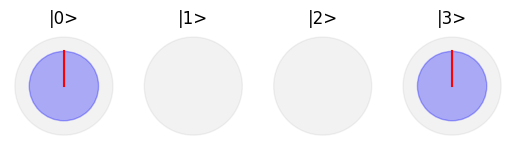

In [ ]:
viz2(complexstates, num_of_qubit=2)

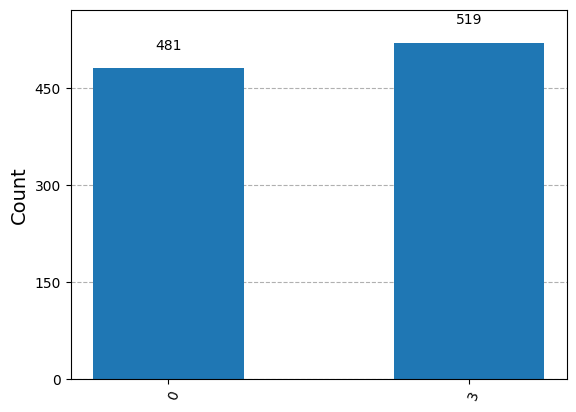

In [ ]:
result = bell.simulation(1000)
plot_histogram(result)

### QFT

In [ ]:
qft = PolarQuantumCircuit(3)

qft.NOT_polar(0)

qft.hadamard_polar(2)
qft.CPHASE_polar(1, 2, np.pi/2)
qft.hadamard_polar(1)
qft.CPHASE_polar(0, 2, np.pi/4)
qft.CPHASE_polar(0, 1, np.pi/2)
qft.hadamard_polar(0)
qft.SWAP_polar(0, 2)

qft.get_circuit_info()


{'num_qubits': 3,
 'gates_applied': [{'gate': 'NOT', 'target': 0},
  {'gate': 'HADAMARD', 'target': 2},
  {'gate': 'CPHASE', 'control': 1, 'target': 2, 'phi': 1.5707963267948966},
  {'gate': 'HADAMARD', 'target': 1},
  {'gate': 'CPHASE', 'control': 0, 'target': 2, 'phi': 0.7853981633974483},
  {'gate': 'CPHASE', 'control': 0, 'target': 1, 'phi': 1.5707963267948966},
  {'gate': 'HADAMARD', 'target': 0},
  {'gate': 'SWAP', 'target1': 0, 'target2': 2}]}

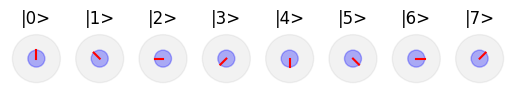

In [ ]:
polarstates = qft.get_state()
complexstates = PolarQuantumCircuit.polar2cartesian(polarstates)
viz2(complexstates, num_of_qubit=3)

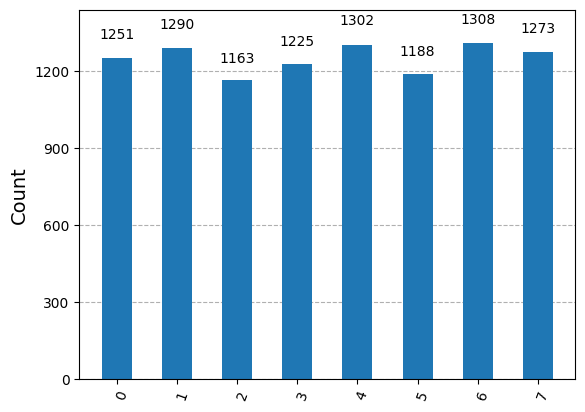

In [ ]:
result = qft.simulation(10000)
plot_histogram(result)

### Grover's

In [ ]:
qcGrover = PolarQuantumCircuit(3)

# initialize
qcGrover.hadamard_polar(0)
qcGrover.hadamard_polar(1)
qcGrover.hadamard_polar(2)

optimalIterNum = 2 # for 3-qubits Grover
for _ in range(optimalIterNum):
  # Oracle marking the key room |6>
  qcGrover.NOT_polar(0)
  qcGrover.CCPHASE_polar([0, 1], 2, np.pi)
  qcGrover.NOT_polar(0)

  # Diffuser
  qcGrover.hadamard_polar(0)
  qcGrover.hadamard_polar(1)
  qcGrover.hadamard_polar(2)
  qcGrover.NOT_polar(0)
  qcGrover.NOT_polar(1)
  qcGrover.NOT_polar(2)
  qcGrover.CCPHASE_polar([0, 1], 2, np.pi)
  qcGrover.NOT_polar(0)
  qcGrover.NOT_polar(1)
  qcGrover.NOT_polar(2)
  qcGrover.hadamard_polar(0)
  qcGrover.hadamard_polar(1)
  qcGrover.hadamard_polar(2)

qcGrover.get_circuit_info()

{'num_qubits': 3,
 'gates_applied': [{'gate': 'HADAMARD', 'target': 0},
  {'gate': 'HADAMARD', 'target': 1},
  {'gate': 'HADAMARD', 'target': 2},
  {'gate': 'NOT', 'target': 0},
  {'gate': 'CCPHASE',
   'control': [0, 1],
   'target': 2,
   'phi': 3.141592653589793},
  {'gate': 'NOT', 'target': 0},
  {'gate': 'HADAMARD', 'target': 0},
  {'gate': 'HADAMARD', 'target': 1},
  {'gate': 'HADAMARD', 'target': 2},
  {'gate': 'NOT', 'target': 0},
  {'gate': 'NOT', 'target': 1},
  {'gate': 'NOT', 'target': 2},
  {'gate': 'CCPHASE',
   'control': [0, 1],
   'target': 2,
   'phi': 3.141592653589793},
  {'gate': 'NOT', 'target': 0},
  {'gate': 'NOT', 'target': 1},
  {'gate': 'NOT', 'target': 2},
  {'gate': 'HADAMARD', 'target': 0},
  {'gate': 'HADAMARD', 'target': 1},
  {'gate': 'HADAMARD', 'target': 2},
  {'gate': 'NOT', 'target': 0},
  {'gate': 'CCPHASE',
   'control': [0, 1],
   'target': 2,
   'phi': 3.141592653589793},
  {'gate': 'NOT', 'target': 0},
  {'gate': 'HADAMARD', 'target': 0},
  {'g

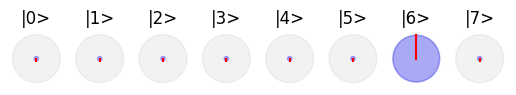

In [ ]:
polarstates = qcGrover.get_state()
complexstates = PolarQuantumCircuit.polar2cartesian(polarstates)
viz2(complexstates, num_of_qubit=3)

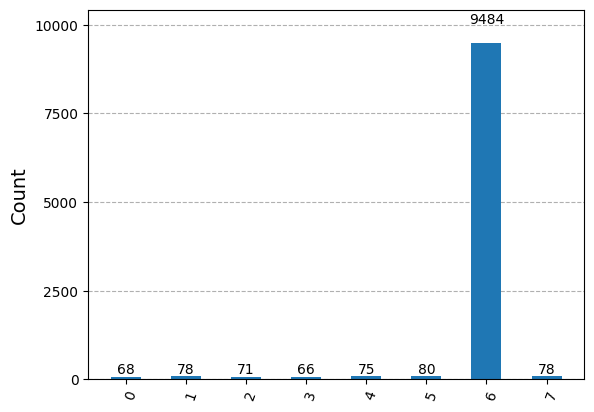

In [ ]:
result = qcGrover.simulation(10000)
plot_histogram(result)

# Implementation details

## additional functions

In [ ]:
def round_number(list_number):
  numbers_array = np.array(list_number)

  small_threshold = 1e-6
  near_one_threshold = 1e-6

  numbers_array[np.abs(numbers_array) < small_threshold] = 0
  numbers_array[np.abs(numbers_array - 1) < near_one_threshold] = 1

  result = numbers_array.tolist()
  return result

In [ ]:
def polar2cartesian(polar_states):
  cartesian_states = [complex(r * math.cos(theta), r * math.sin(theta)) for r, theta in polar_states]
  return cartesian_states

def cartesian2polar(cartesian_states):
  polar_states = [(math.sqrt(complexelement.real**2 + complexelement.imag**2), math.atan2(complexelement.imag, complexelement.real)) for complexelement in cartesian_states]
  return polar_states

## NOT for polar (correct)

In [ ]:
def NOT_polar(state, target_qubit, num_qubits):
    num_states = 2**num_qubits
    new_state = state.copy()

    for i in range(num_states):
        # Check if the target qubit is 0 or 1
        if (i >> target_qubit) & 1 == 0:
            index_0 = i
            index_1 = i | (1 << target_qubit)
        else:
            index_0 = i & ~(1 << target_qubit)
            index_1 = i

        # Update the new state
        new_state[index_0] = state[index_1]
        new_state[index_1] = state[index_0]

    return new_state

In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

statevector_init = Statevector(qc)

qc.x(0)
qc.barrier()
statevector0 = Statevector(qc)

qc.x(1)
qc.barrier()
statevector1 = Statevector(qc)

qc.x(2)
qc.barrier()
statevector2 = Statevector(qc)

qc.x(0)
qc.barrier()
statevector0_1 = Statevector(qc)

qc.x(1)
qc.barrier()
statevector1_1 = Statevector(qc)

qc.x(2)
qc.barrier()
statevector2_1 = Statevector(qc)

qc.draw()

┌───┐ ░       ░       ░ ┌───┐ ░       ░       ░ 
q_0: ┤ X ├─░───────░───────░─┤ X ├─░───────░───────░─
     └───┘ ░ ┌───┐ ░       ░ └───┘ ░ ┌───┐ ░       ░ 
q_1: ──────░─┤ X ├─░───────░───────░─┤ X ├─░───────░─
           ░ └───┘ ░ ┌───┐ ░       ░ └───┘ ░ ┌───┐ ░ 
q_2: ──────░───────░─┤ X ├─░───────░───────░─┤ X ├─░─
           ░       ░ └───┘ ░       ░       ░ └───┘ ░

qiskit:
Polar: [(1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(1+0j), 0j, 0j, 0j, 0j, 0j, 0j, 0j]


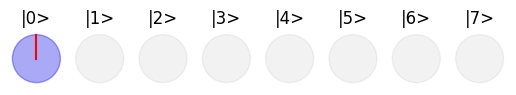

my:
Polar: [(1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(1+0j), 0j, 0j, 0j, 0j, 0j, 0j, 0j]


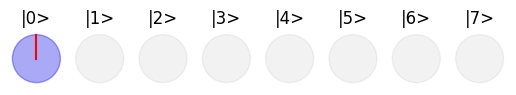

Difference is less than 1e-6: True


In [ ]:
num_qubits = 3
init_state = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {init_state}")
print(f"Cartesian: {polar2cartesian(init_state)}")
viz2(polar2cartesian(init_state))

print(f"Difference is less than 1e-6: {(abs(np.array(init_state)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

qiskit:
Polar: [(0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 0j]


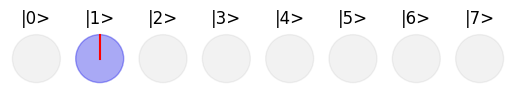

my:
Polar: [[0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 0j]


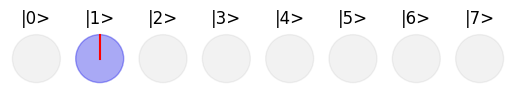

Difference is less than 1e-6: True
qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j]


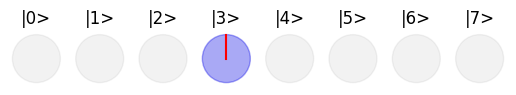

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j]


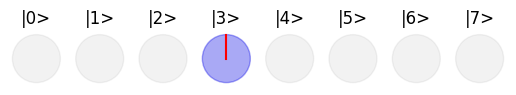

Difference is less than 1e-6: True
qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0)]
Cartesian: [0j, 0j, 0j, 0j, 0j, 0j, 0j, (1+0j)]


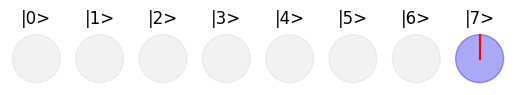

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0]]
Cartesian: [0j, 0j, 0j, 0j, 0j, 0j, 0j, (1+0j)]


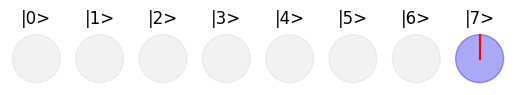

Difference is less than 1e-6: True


In [ ]:
apply_NOT = round_number(NOT_polar(init_state, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector0)}")
print(f"Cartesian: {list(statevector0)}")
viz2(Statevector(statevector0))
print(f"my:")
print(f"Polar: {apply_NOT}")
print(f"Cartesian: {polar2cartesian(apply_NOT)}")
viz2(polar2cartesian(apply_NOT))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_NOT)-np.array(cartesian2polar(statevector0)))<1e-6).all()}")

apply_NOT = round_number(NOT_polar(apply_NOT, 1, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {apply_NOT}")
print(f"Cartesian: {polar2cartesian(apply_NOT)}")
viz2(polar2cartesian(apply_NOT))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_NOT)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

apply_NOT = round_number(NOT_polar(apply_NOT, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2)}")
print(f"Cartesian: {list(statevector2)}")
viz2(Statevector(statevector2))
print(f"my:")
print(f"Polar: {apply_NOT}")
print(f"Cartesian: {polar2cartesian(apply_NOT)}")
viz2(polar2cartesian(apply_NOT))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_NOT)-np.array(cartesian2polar(statevector2)))<1e-6).all()}")

qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, 0j, 0j, 0j, 0j, (1+0j), 0j]


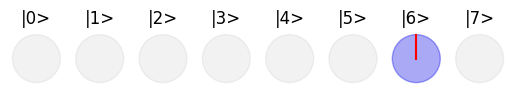

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, 0j, 0j, 0j, 0j, 0j, (1+0j), 0j]


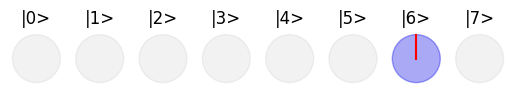

Difference is less than 1e-6: True
qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, 0j, 0j, (1+0j), 0j, 0j, 0j]


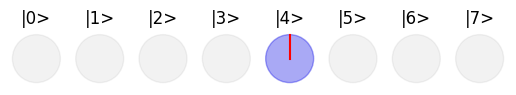

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, 0j, 0j, 0j, (1+0j), 0j, 0j, 0j]


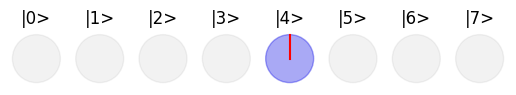

Difference is less than 1e-6: True
qiskit:
Polar: [(1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(1+0j), 0j, 0j, 0j, 0j, 0j, 0j, 0j]


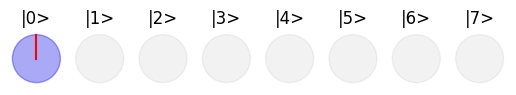

my:
Polar: [[1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [(1+0j), 0j, 0j, 0j, 0j, 0j, 0j, 0j]


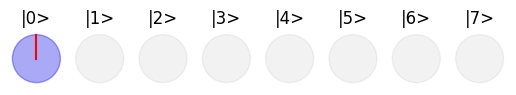

Difference is less than 1e-6: True


In [ ]:
apply_NOT = round_number(NOT_polar(apply_NOT, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector0_1)}")
print(f"Cartesian: {list(statevector0_1)}")
viz2(Statevector(statevector0_1))
print(f"my:")
print(f"Polar: {apply_NOT}")
print(f"Cartesian: {polar2cartesian(apply_NOT)}")
viz2(polar2cartesian(apply_NOT))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_NOT)-np.array(cartesian2polar(statevector0_1)))<1e-6).all()}")

apply_NOT = round_number(NOT_polar(apply_NOT, 1, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1_1)}")
print(f"Cartesian: {list(statevector1_1)}")
viz2(Statevector(statevector1_1))
print(f"my:")
print(f"Polar: {apply_NOT}")
print(f"Cartesian: {polar2cartesian(apply_NOT)}")
viz2(polar2cartesian(apply_NOT))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_NOT)-np.array(cartesian2polar(statevector1_1)))<1e-6).all()}")

apply_NOT = round_number(NOT_polar(apply_NOT, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2_1)}")
print(f"Cartesian: {list(statevector2_1)}")
viz2(Statevector(statevector2_1))
print(f"my:")
print(f"Polar: {apply_NOT}")
print(f"Cartesian: {polar2cartesian(apply_NOT)}")
viz2(polar2cartesian(apply_NOT))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_NOT)-np.array(cartesian2polar(statevector2_1)))<1e-6).all()}")

## hadamard for polar (correct)

In [ ]:
def hadamard_polar_matrix(target_qubit, num_qubits):
    """
    Constructs the Hadamard gate matrix for a specific qubit in an n-qubit system
    in polar representation.

    Parameters:
        target_qubit: int
                      The index of the target qubit (0-indexed).
        num_qubits: int
                    Total number of qubits in the system.

    Returns:
        H: list of functions
           A list of functions that compute the new polar amplitudes for each basis state.
    """
    num_states = 2**num_qubits

    def compute_new_state(r0, theta0, r1, theta1):
        """
        Computes the new polar amplitudes for a given pair of states.
        """
        # # translate to complex before calculation
        # real_0 = r0 * np.cos(theta0) + r1 * np.cos(theta1)
        # imag_0 = r0 * np.sin(theta0) + r1 * np.sin(theta1)
        # r_new_0 = np.sqrt(0.5 * (real_0**2 + imag_0**2))
        # theta_new_0 = np.arctan2(imag_0, real_0)

        # real_1 = r0 * np.cos(theta0) - r1 * np.cos(theta1)
        # imag_1 = r0 * np.sin(theta0) - r1 * np.sin(theta1)
        # r_new_1 = np.sqrt(0.5 * (real_1**2 + imag_1**2))
        # theta_new_1 = np.arctan2(imag_1, real_1)

        # calculate by the rotating property of complex number
        delta_theta = theta1 - theta0
        r_new_0 = np.sqrt(0.5 * ((r0 + r1 * np.cos(delta_theta)) ** 2 + (r1 * np.sin(delta_theta)) ** 2))
        theta_new_0 = theta0 + np.arctan2(r1 * np.sin(delta_theta), r0 + r1 * np.cos(delta_theta))
        if theta_new_0 < 0:
          theta_new_0 += np.pi * 2
        if abs(theta_new_0 - np.pi * 2) < 1e-6:
          theta_new_0 = 0.
        r_new_1 = np.sqrt(0.5 * ((r0 - r1 * np.cos(delta_theta)) ** 2 + (r1 * np.sin(delta_theta)) ** 2))
        theta_new_1 = theta0 + np.arctan2(- r1 * np.sin(delta_theta), r0 - r1 * np.cos(delta_theta))
        if theta_new_1 < 0:
          theta_new_1 += np.pi * 2
        if abs(theta_new_1 - np.pi * 2) < 1e-6:
          theta_new_1 = 0.
        return (r_new_0, theta_new_0, r_new_1, theta_new_1)

    # Define the polar transformation matrix
    H_polar = []

    for i in range(num_states):
        # For each basis state, determine if target qubit is 0 or 1
        index_0 = i
        index_1 = i
        if (i >> target_qubit) & 1 == 0:
            index_0 = i
            index_1 = i | (1 << target_qubit)
            # partner = i | (1 << target_qubit)  # Corresponding |1> state
        else:
            index_0 = i & ~(1 << target_qubit)
            index_1 = i
            # partner = i & ~(1 << target_qubit)  # Corresponding |0> state

        # Append transformation functions for this state pair
        H_polar.append((index_0, index_1, compute_new_state))

    return H_polar
def apply_hadamard_polar(state, H_polar, num_qubits):
    """
    Applies the Hadamard gate in polar representation to the quantum state.

    Parameters:
        state: list of tuples [(r0, theta0), (r1, theta1), ...]
               The polar representation of the quantum state.
        H_polar: list
                 The transformation matrix from hadamard_polar_matrix.
        num_qubits: int
                    Total number of qubits in the system.

    Returns:
        new_state: list of tuples [(r0', theta0'), (r1', theta1'), ...]
                   The transformed state in polar form.
    """
    new_state = state.copy()

    for i, partner, transform_fn in H_polar:
        # Get current polar amplitudes
        r0, theta0 = state[i]
        r1, theta1 = state[partner]

        # Compute new polar amplitudes
        r_new_0, theta_new_0, r_new_1, theta_new_1 = transform_fn(r0, theta0, r1, theta1)

        # Update new state
        new_state[i] = (r_new_0, theta_new_0)
        new_state[partner] = (r_new_1, theta_new_1)

    return new_state
def hadamard_polar(state, target_qubit, num_qubits):
    num_states = 2**num_qubits
    new_state = state.copy()

    for i in range(num_states):
        # Check if the target qubit is 0 or 1
        if (i >> target_qubit) & 1 == 0:
            index_0 = i
            index_1 = i | (1 << target_qubit)
        else:
            index_0 = i & ~(1 << target_qubit)
            index_1 = i

        # Get the polar components for |0> and |1> of the target qubit
        r0, theta0 = state[index_0]
        r1, theta1 = state[index_1]

        # calculate by the rotating property of complex number
        delta_theta = theta1 - theta0
        r_new_0 = np.sqrt(0.5 * ((r0 + r1 * np.cos(delta_theta)) ** 2 + (r1 * np.sin(delta_theta)) ** 2))
        theta_new_0 = theta0 + np.arctan2(r1 * np.sin(delta_theta), r0 + r1 * np.cos(delta_theta))
        if theta_new_0 < 0:
          theta_new_0 += np.pi * 2
        if abs(theta_new_0 - np.pi * 2) < 1e-6:
          theta_new_0 = 0.
        r_new_1 = np.sqrt(0.5 * ((r0 - r1 * np.cos(delta_theta)) ** 2 + (r1 * np.sin(delta_theta)) ** 2))
        theta_new_1 = theta0 + np.arctan2(- r1 * np.sin(delta_theta), r0 - r1 * np.cos(delta_theta))
        if theta_new_1 < 0:
          theta_new_1 += np.pi * 2
        if abs(theta_new_1 - np.pi * 2) < 1e-6:
          theta_new_1 = 0.

        # Update the new state
        new_state[index_0] = [r_new_0, theta_new_0]
        new_state[index_1] = [r_new_1, theta_new_1]
    for i in range(num_states):
      if new_state[i][1] < -np.pi and abs(new_state[i][1]+np.pi) > 1e-4:
        new_state[i][1] += np.pi * 2
      if new_state[i][1] > np.pi and abs(new_state[i][1]-np.pi) > 1e-4:
        new_state[i][1] -= np.pi * 2
    return new_state

In [ ]:
H_polar = hadamard_polar_matrix(0,3)
H_polar

[(0,
  1,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>),
 (0,
  1,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>),
 (2,
  3,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>),
 (2,
  3,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>),
 (4,
  5,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>),
 (4,
  5,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>),
 (6,
  7,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>),
 (6,
  7,
  <function __main__.hadamard_polar_matrix.<locals>.compute_new_state(r0, theta0, r1, theta1)>)]

### comparision

In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(1)
qc.x(0)
qc.barrier()

statevector1 = Statevector(qc)

qc.h(0)
qc.barrier()
statevector2 = Statevector(qc)
qc.h(1)
qc.barrier()
statevector2_1 = Statevector(qc)
qc.h(2)
qc.barrier()
statevector2_2 = Statevector(qc)

qc.h(0)
qc.barrier()
statevector3 = Statevector(qc)
qc.h(1)
qc.barrier()
statevector3_1 = Statevector(qc)
qc.h(2)
qc.barrier()
statevector3_2 = Statevector(qc)
qc.draw()

┌───┐ ░ ┌───┐ ░       ░       ░ ┌───┐ ░       ░       ░ 
q_0: ┤ X ├─░─┤ H ├─░───────░───────░─┤ H ├─░───────░───────░─
     ├───┤ ░ └───┘ ░ ┌───┐ ░       ░ └───┘ ░ ┌───┐ ░       ░ 
q_1: ┤ X ├─░───────░─┤ H ├─░───────░───────░─┤ H ├─░───────░─
     └───┘ ░       ░ └───┘ ░ ┌───┐ ░       ░ └───┘ ░ ┌───┐ ░ 
q_2: ──────░───────░───────░─┤ H ├─░───────░───────░─┤ H ├─░─
           ░       ░       ░ └───┘ ░       ░       ░ └───┘ ░

qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j]


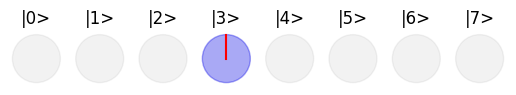

my:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j]


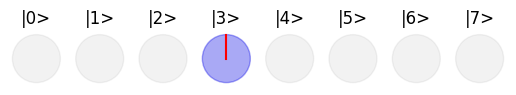

Difference is less than 1e-6: True


In [ ]:
num_qubits = 3
init_state = [(1.0 if i == 3 else 0.0, 0.0) for i in range(2**num_qubits)]
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {init_state}")
print(f"Cartesian: {polar2cartesian(init_state)}")
viz2(polar2cartesian(init_state))

print(f"Difference is less than 1e-6: {(abs(np.array(init_state)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.7071067811865475, 0.0), (0.7071067811865475, 3.141592653589793), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, (0.7071067811865475+0j), (-0.7071067811865475+0j), 0j, 0j, 0j, 0j]


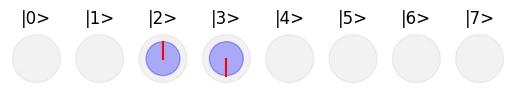

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.7071067811865476, 0.0], [0.7071067811865476, 3.141592653589793], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, 0j, (0.7071067811865476+0j), (-0.7071067811865476+8.659560562354934e-17j), 0j, 0j, 0j, 0j]


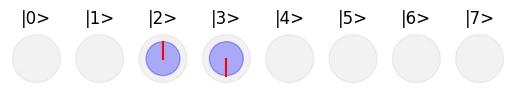

Difference is less than 1e-6: True
qiskit:
Polar: [(0.4999999999999999, 0.0), (0.4999999999999999, 3.141592653589793), (0.4999999999999999, 3.141592653589793), (0.4999999999999999, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(0.4999999999999999+0j), (-0.4999999999999999+0j), (-0.4999999999999999+0j), (0.4999999999999999+0j), 0j, 0j, 0j, 0j]


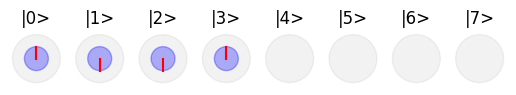

my:
Polar: [[0.5, 0.0], [0.5, 3.141592653589793], [0.5, 3.141592653589793], [0.5, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [(0.5+0j), (-0.5+6.123233995736766e-17j), (-0.5+6.123233995736766e-17j), (0.5+0j), 0j, 0j, 0j, 0j]


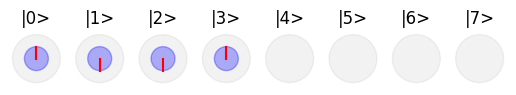

Difference is less than 1e-6: True
qiskit:
Polar: [(0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0)]
Cartesian: [(0.3535533905932737+0j), (-0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j)]


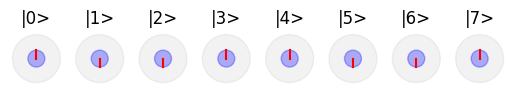

my:
Polar: [[0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0]]
Cartesian: [(0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j)]


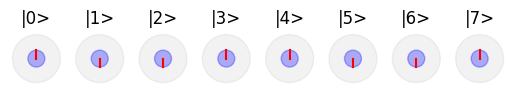

Difference is less than 1e-6: True


In [ ]:
# apply_hadamard = round_number(apply_hadamard_polar(init_state, hadamard_polar_matrix(0, num_qubits), num_qubits))
apply_hadamard = round_number(hadamard_polar(init_state, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2)}")
print(f"Cartesian: {list(statevector2)}")
viz2(Statevector(statevector2))
print(f"my:")
print(f"Polar: {apply_hadamard}")
print(f"Cartesian: {polar2cartesian(apply_hadamard)}")
viz2(polar2cartesian(apply_hadamard))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_hadamard)-np.array(cartesian2polar(statevector2)))<1e-6).all()}")

# apply_hadamard = round_number(apply_hadamard_polar(apply_hadamard, hadamard_polar_matrix(1, num_qubits), num_qubits))
apply_hadamard = round_number(hadamard_polar(apply_hadamard, 1, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2_1)}")
print(f"Cartesian: {list(statevector2_1)}")
viz2(Statevector(statevector2_1))
print(f"my:")
print(f"Polar: {apply_hadamard}")
print(f"Cartesian: {polar2cartesian(apply_hadamard)}")
viz2(polar2cartesian(apply_hadamard))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_hadamard)-np.array(cartesian2polar(statevector2_1)))<1e-6).all()}")

# apply_hadamard = round_number(apply_hadamard_polar(apply_hadamard, hadamard_polar_matrix(2, num_qubits), num_qubits))
apply_hadamard = round_number(hadamard_polar(apply_hadamard, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2_2)}")
print(f"Cartesian: {list(statevector2_2)}")
viz2(Statevector(statevector2_2))
print(f"my:")
print(f"Polar: {apply_hadamard}")
print(f"Cartesian: {polar2cartesian(apply_hadamard)}")
viz2(polar2cartesian(apply_hadamard))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_hadamard)-np.array(cartesian2polar(statevector2_2)))<1e-6).all()}")

qiskit:
Polar: [(3.1116426608676864e-19, 0.0), (0.49999999999999983, 0.0), (3.1116426608676864e-19, 3.141592653589793), (0.49999999999999983, 3.141592653589793), (3.1116426608676864e-19, 0.0), (0.49999999999999983, 0.0), (3.1116426608676864e-19, 3.141592653589793), (0.49999999999999983, 3.141592653589793)]
Cartesian: [(3.1116426608676864e-19+0j), (0.49999999999999983+0j), (-3.1116426608676864e-19+0j), (-0.49999999999999983+0j), (3.1116426608676864e-19+0j), (0.49999999999999983+0j), (-3.1116426608676864e-19+0j), (-0.49999999999999983+0j)]


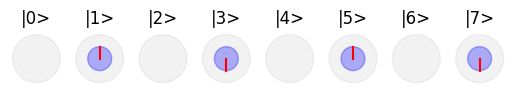

my:
Polar: [[0.0, 1.5707963267948966], [0.5, 0.0], [0.0, 1.5707963267948966], [0.5, 3.141592653589793], [0.0, 1.5707963267948966], [0.5, 0.0], [0.0, 1.5707963267948966], [0.5, 3.141592653589793]]
Cartesian: [0j, (0.5+0j), 0j, (-0.5+6.123233995736766e-17j), 0j, (0.5+0j), 0j, (-0.5+6.123233995736766e-17j)]


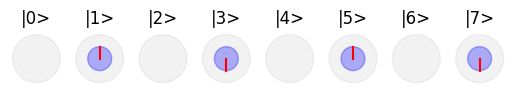

Difference is less than 1e-6: False
qiskit:
Polar: [(1.3580582744750046e-35, 0.0), (6.734631938767465e-18, 0.0), (4.400527252257787e-19, 0.0), (0.7071067811865472, 0.0), (1.3580582744750046e-35, 0.0), (6.734631938767465e-18, 0.0), (4.400527252257787e-19, 0.0), (0.7071067811865472, 0.0)]
Cartesian: [(1.3580582744750046e-35+0j), (6.734631938767465e-18+0j), (4.400527252257787e-19+0j), (0.7071067811865472+0j), (1.3580582744750046e-35+0j), (6.734631938767465e-18+0j), (4.400527252257787e-19+0j), (0.7071067811865472+0j)]


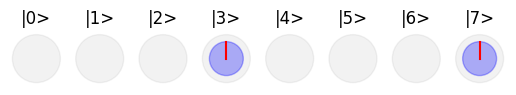

my:
Polar: [[0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [0.7071067811865476, 0.0], [0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [0.7071067811865476, 0.0]]
Cartesian: [0j, 0j, 0j, (0.7071067811865476+0j), 0j, 0j, 0j, (0.7071067811865476+0j)]


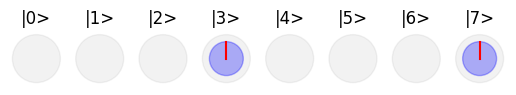

Difference is less than 1e-6: False
qiskit:
Polar: [(1.9205844302555546e-35, 0.0), (9.52420782539596e-18, 0.0), (6.223285321735372e-19, 0.0), (0.9999999999999996, 0.0), (1.905050747901445e-52, 0.0), (1.2631615347037043e-34, 0.0), (1.2183947074714076e-35, 3.141592653589793), (2.3615800235104456e-17, 0.0)]
Cartesian: [(1.9205844302555546e-35+0j), (9.52420782539596e-18+0j), (6.223285321735372e-19+0j), (0.9999999999999996+0j), (1.905050747901445e-52+0j), (1.2631615347037043e-34+0j), (-1.2183947074714076e-35+0j), (2.3615800235104456e-17+0j)]


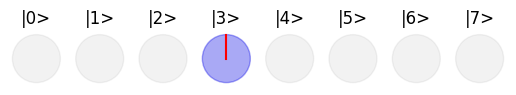

my:
Polar: [[0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [1.0, 0.0], [0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [0.0, 1.5707963267948966], [0.0, 0.0]]
Cartesian: [0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j]


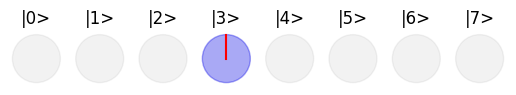

Difference is less than 1e-6: False


In [ ]:
# apply_hadamard = round_number(apply_hadamard_polar(apply_hadamard, hadamard_polar_matrix(0, num_qubits), num_qubits))
apply_hadamard = round_number(hadamard_polar(apply_hadamard, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector3)}")
print(f"Cartesian: {list(statevector3)}")
viz2(Statevector(statevector3))
print(f"my:")
print(f"Polar: {apply_hadamard}")
print(f"Cartesian: {polar2cartesian(apply_hadamard)}")
viz2(polar2cartesian(apply_hadamard))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_hadamard)-np.array(cartesian2polar(statevector3)))<1e-6).all()}")

# apply_hadamard = round_number(apply_hadamard_polar(apply_hadamard, hadamard_polar_matrix(1, num_qubits), num_qubits))
apply_hadamard = round_number(hadamard_polar(apply_hadamard, 1, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector3_1)}")
print(f"Cartesian: {list(statevector3_1)}")
viz2(Statevector(statevector3_1))
print(f"my:")
print(f"Polar: {apply_hadamard}")
print(f"Cartesian: {polar2cartesian(apply_hadamard)}")
viz2(polar2cartesian(apply_hadamard))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_hadamard)-np.array(cartesian2polar(statevector3_1)))<1e-6).all()}")

# apply_hadamard = round_number(apply_hadamard_polar(apply_hadamard, hadamard_polar_matrix(2, num_qubits), num_qubits))
apply_hadamard = round_number(hadamard_polar(apply_hadamard, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector3_2)}")
print(f"Cartesian: {list(statevector3_2)}")
viz2(Statevector(statevector3_2))
print(f"my:")
print(f"Polar: {apply_hadamard}")
print(f"Cartesian: {polar2cartesian(apply_hadamard)}")
viz2(polar2cartesian(apply_hadamard))
print(f"Difference is less than 1e-6: {(abs(np.array(apply_hadamard)-np.array(cartesian2polar(statevector3_2)))<1e-6).all()}")

In [ ]:
# import numpy as np

# def hadamard_polar_multiple_qubits(state, target_qubits, num_qubits):
#     """
#     Applies Hadamard gates to multiple qubits in a multi-qubit system in polar form.

#     Parameters:
#         state: list of tuples [(r0, theta0), (r1, theta1), ...]
#                Polar representation of the quantum state.
#         target_qubits: list of int
#                        List of target qubits (0-indexed) where Hadamard gates are applied.
#         num_qubits: int
#                     Total number of qubits in the system.

#     Returns:
#         new_state: list of tuples [(r0', theta0'), (r1', theta1'), ...]
#                    The transformed state in polar form.
#     """
#     num_states = 2**num_qubits
#     new_state = state.copy()

#     for target_qubit in target_qubits:
#         for i in range(num_states):
#             # Check if the target qubit is 0 or 1
#             if (i >> target_qubit) & 1 == 0:  # If target qubit is 0
#                 partner = i | (1 << target_qubit)  # Find the corresponding |1> state
#             else:  # If target qubit is 1
#                 partner = i & ~(1 << target_qubit)  # Find the corresponding |0> state

#             # Get the polar components for |0> and |1> of the target qubit
#             r0, theta0 = new_state[i]
#             r1, theta1 = new_state[partner]

#             # Compute new amplitudes for |0> and |1>
#             delta_theta = theta1 - theta0
#             real_0 = r0 + r1 * np.cos(delta_theta)
#             imag_0 = r1 * np.sin(delta_theta)
#             r_new_0 = np.sqrt(0.5 * (real_0**2 + imag_0**2))
#             theta_new_0 = theta0 + np.arctan2(imag_0, real_0)

#             real_1 = r0 - r1 * np.cos(delta_theta)
#             imag_1 = -r1 * np.sin(delta_theta)
#             r_new_1 = np.sqrt(0.5 * (real_1**2 + imag_1**2))
#             theta_new_1 = theta0 + np.pi + np.arctan2(imag_1, real_1)

#             # Update the new state
#             new_state[i] = (r_new_0, theta_new_0)
#             new_state[partner] = (r_new_1, theta_new_1)

#     return new_state

# # Example Usage
# num_qubits = 3
# initial_state = [(1.0 if i == 1 else 0.0, 0.0) for i in range(2**num_qubits)]

# # Apply Hadamard to the first and second qubits
# target_qubits = [0, 1]
# transformed_state = hadamard_polar_multiple_qubits(initial_state, target_qubits, num_qubits)

# # Print the transformed state
# for i, (r, theta) in enumerate(transformed_state):
#     print(f"State |{format(i, f'0{num_qubits}b')}>: Magnitude = {r:.4f}, Phase = {theta:.4f}")


## test for NOT and Hadamard (correct)

In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(0)
qc.x(2)
qc.barrier()

statevector_init = Statevector(qc)

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()
statevector1 = Statevector(qc)

qc.x(0)
qc.barrier()
statevector2 = Statevector(qc)

qc.draw()

┌───┐ ░ ┌───┐ ░ ┌───┐ ░ 
q_0: ┤ X ├─░─┤ H ├─░─┤ X ├─░─
     └───┘ ░ ├───┤ ░ └───┘ ░ 
q_1: ──────░─┤ H ├─░───────░─
     ┌───┐ ░ ├───┤ ░       ░ 
q_2: ┤ X ├─░─┤ H ├─░───────░─
     └───┘ ░ └───┘ ░       ░

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, 0j, 0j, 0j, (1+0j), 0j, 0j]


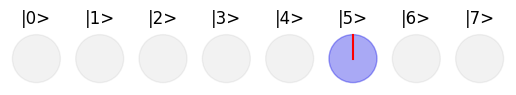

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, 0j, 0j, 0j, 0j, (1+0j), 0j, 0j]


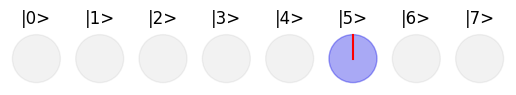

Difference is less than 1e-6: True
qiskit:
Polar: [(0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0)]
Cartesian: [(0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j)]


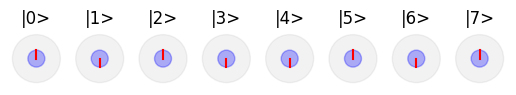

my:
Polar: [[0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0]]
Cartesian: [(0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j)]


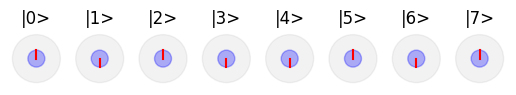

Difference is less than 1e-6: True
qiskit:
Polar: [(0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793)]
Cartesian: [(-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j)]


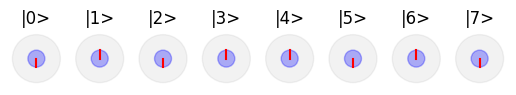

my:
Polar: [[0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793]]
Cartesian: [(-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j)]


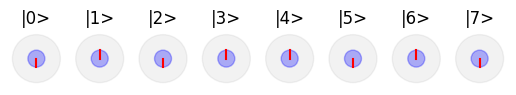

Difference is less than 1e-6: True


In [ ]:
result = round_number(NOT_polar(init_qc, 0, num_qubits))
result = round_number(NOT_polar(result, 2, num_qubits))

print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

result = round_number(hadamard_polar(result, 0, num_qubits))
result = round_number(hadamard_polar(result, 1, num_qubits))
result = round_number(hadamard_polar(result, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

result = round_number(NOT_polar(result, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2)}")
print(f"Cartesian: {list(statevector2)}")
viz2(Statevector(statevector2))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector2)))<1e-6).all()}")

## READ for polar (correct)

In [ ]:
def READ_polar_singlequbit(state, target_qubit, num_qubits, num_shots=1):
    num_states = 2**num_qubits
    amplitute0, amplitute1 = 0, 0
    for i in range(num_states):
    # Check if the target qubit is 0 or 1
        if (i >> target_qubit) & 1 == 0:
            amplitute0 += np.square(state[i][0])
        else:
            amplitute1 += np.square(state[i][0])

    prob_qubit = [amplitute0, amplitute1]

    possible_outcome = np.arange(2)
    measurement = dict()
    for i in possible_outcome:
      measurement[str(i)] = 0
    # print(measurement)
    for i in range(num_shots):
      x = random.choices(possible_outcome, weights=prob_qubit)[0]
      measurement[str(x)] += 1
    return measurement

def READ_polar_all(state, num_qubits, num_shots=1):
    num_states = 2**num_qubits
    amplitute = []
    for i in range(num_states):
      amplitute.append(np.square(state[i][0]))

    possible_outcome = np.arange(num_states)
    measurement = dict()
    for i in possible_outcome:
      measurement[str(i)] = 0

    for i in range(num_shots):
      x = random.choices(possible_outcome, weights=amplitute)[0]
      measurement[str(x)] += 1
    return measurement

In [ ]:
num_qubits = 3
qr = QuantumRegister(num_qubits, "qubit")
cr = ClassicalRegister(1)
qc = QuantumCircuit(qr, cr)

qc.x(0)
qc.barrier()
statevector_init = Statevector(qc)

qc.h(0)
qc.barrier()
statevector1 = Statevector(qc)

qc.measure(0, 0)
qc.draw()

┌───┐ ░ ┌───┐ ░ ┌─┐
qubit_0: ┤ X ├─░─┤ H ├─░─┤M├
         └───┘ ░ └───┘ ░ └╥┘
qubit_1: ──────░───────░──╫─
               ░       ░  ║ 
qubit_2: ──────░───────░──╫─
               ░       ░  ║ 
   c0: 1/═════════════════╩═
                          0

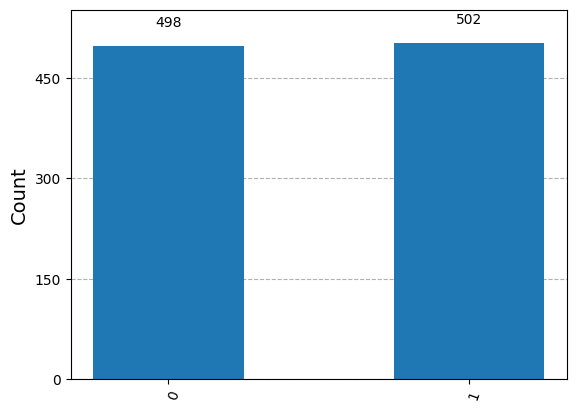

In [ ]:
simulator = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, simulator)

job = simulator.run(transpiled_circuit, shots=1000)
job.result().get_counts()
plot_histogram(job.result().get_counts())

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 0j]


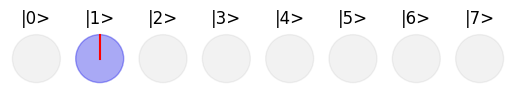

my:
Polar: [[0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 0j]


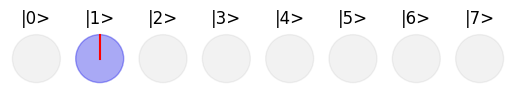

Difference is less than 1e-6: True
qiskit:
Polar: [(0.7071067811865475, 0.0), (0.7071067811865475, 3.141592653589793), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(0.7071067811865475+0j), (-0.7071067811865475+0j), 0j, 0j, 0j, 0j, 0j, 0j]


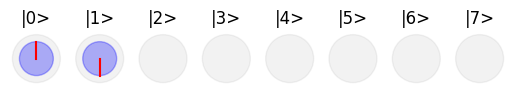

my:
Polar: [[0.7071067811865476, 0.0], [0.7071067811865476, 3.141592653589793], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [(0.7071067811865476+0j), (-0.7071067811865476+8.659560562354934e-17j), 0j, 0j, 0j, 0j, 0j, 0j]


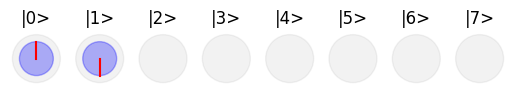

Difference is less than 1e-6: True
{'0': 508, '1': 492}
{'0': 512, '1': 488, '2': 0, '3': 0, '4': 0, '5': 0, '6': 0, '7': 0}


In [ ]:
result = round_number(NOT_polar(init_qc, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

result = round_number(hadamard_polar(result, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

measure_result = READ_polar_singlequbit(result, 0, num_qubits, num_shots=1000)
print(measure_result)
measure_result = READ_polar_all(result, num_qubits, num_shots=1000)
print(measure_result)

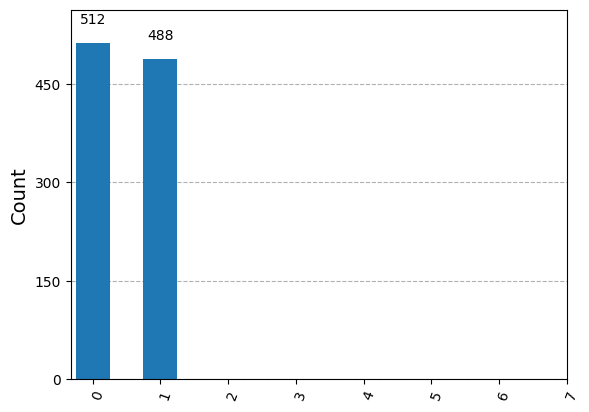

In [ ]:
plot_histogram(measure_result)

## CNOT for polar (correct)

In [ ]:
def CNOT_polar(state, control_qubit, target_qubit, num_qubits):
    num_states = 2**num_qubits
    new_state = state.copy()

    for i in range(num_states):
        # Check if the target qubit is 0 or 1
        if (i >> control_qubit) & 1 != 0:
            if (i >> target_qubit) & 1 == 0:
                index_0 = i
                index_1 = i | (1 << target_qubit)
            else:
                index_0 = i & ~(1 << target_qubit)
                index_1 = i

            # Update the new state
            new_state[index_0] = state[index_1]
            new_state[index_1] = state[index_0]

    return new_state

In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(0)
qc.barrier()
statevector_init = Statevector(qc)

qc.h(0)
qc.barrier()
statevector1 = Statevector(qc)

qc.cx(0, 2)
qc.barrier()
statevector2 = Statevector(qc)

qc.draw()

┌───┐ ░ ┌───┐ ░       ░ 
q_0: ┤ X ├─░─┤ H ├─░───■───░─
     └───┘ ░ └───┘ ░   │   ░ 
q_1: ──────░───────░───┼───░─
           ░       ░ ┌─┴─┐ ░ 
q_2: ──────░───────░─┤ X ├─░─
           ░       ░ └───┘ ░

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 0j]


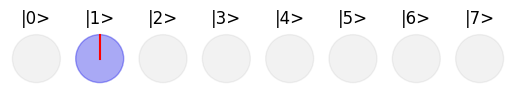

my:
Polar: [[0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, (1+0j), 0j, 0j, 0j, 0j, 0j, 0j]


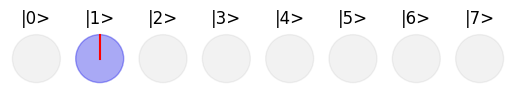

Difference is less than 1e-6: True
qiskit:
Polar: [(0.7071067811865475, 0.0), (0.7071067811865475, 3.141592653589793), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(0.7071067811865475+0j), (-0.7071067811865475+0j), 0j, 0j, 0j, 0j, 0j, 0j]


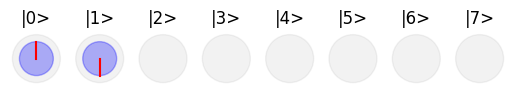

my:
Polar: [[0.7071067811865476, 0.0], [0.7071067811865476, 3.141592653589793], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [(0.7071067811865476+0j), (-0.7071067811865476+8.659560562354934e-17j), 0j, 0j, 0j, 0j, 0j, 0j]


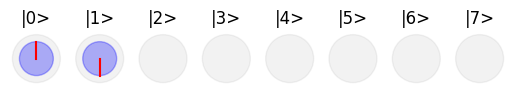

Difference is less than 1e-6: True
qiskit:
Polar: [(0.7071067811865475, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.7071067811865475, 3.141592653589793), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(0.7071067811865475+0j), 0j, 0j, 0j, 0j, (-0.7071067811865475+0j), 0j, 0j]


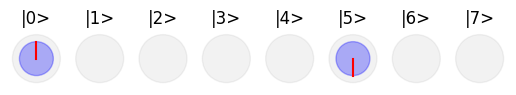

my:
Polar: [[0.7071067811865476, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.7071067811865476, 3.141592653589793], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [(0.7071067811865476+0j), 0j, 0j, 0j, 0j, (-0.7071067811865476+8.659560562354934e-17j), 0j, 0j]


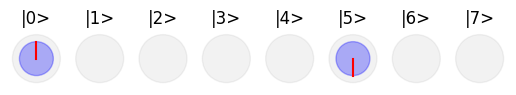

Difference is less than 1e-6: True


In [ ]:
result = round_number(NOT_polar(init_qc, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

result = round_number(hadamard_polar(result, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

result = round_number(CNOT_polar(result, 0, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2)}")
print(f"Cartesian: {list(statevector2)}")
viz2(Statevector(statevector2))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector2)))<1e-6).all()}")

## MCX for polar (correct)

In [ ]:
def MCX_polar(state, control_qubits, target_qubit, num_qubits):
    num_states = 2**num_qubits
    new_state = state.copy()

    for i in range(num_states):
        # Check if the target qubit is 0 or 1
        flag = True
        for j in control_qubits:
          if (i >> j) & 1 == 0:
            flag = False
        if flag:
            if (i >> target_qubit) & 1 == 0:
                index_0 = i
                index_1 = i | (1 << target_qubit)
            else:
                index_0 = i & ~(1 << target_qubit)
                index_1 = i

            # Update the new state
            new_state[index_0] = state[index_1]
            new_state[index_1] = state[index_0]

    return new_state

In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(0)
qc.x(1)
qc.barrier()
statevector_init = Statevector(qc)

qc.h(0)
qc.barrier()
statevector1 = Statevector(qc)

qc.mcx([0,1], 2)
qc.barrier()
statevector2 = Statevector(qc)

qc.measure_all()
qc.draw()

┌───┐ ░ ┌───┐ ░       ░  ░ ┌─┐      
   q_0: ┤ X ├─░─┤ H ├─░───■───░──░─┤M├──────
        ├───┤ ░ └───┘ ░   │   ░  ░ └╥┘┌─┐   
   q_1: ┤ X ├─░───────░───■───░──░──╫─┤M├───
        └───┘ ░       ░ ┌─┴─┐ ░  ░  ║ └╥┘┌─┐
   q_2: ──────░───────░─┤ X ├─░──░──╫──╫─┤M├
              ░       ░ └───┘ ░  ░  ║  ║ └╥┘
meas: 3/════════════════════════════╩══╩══╩═
                                    0  1  2

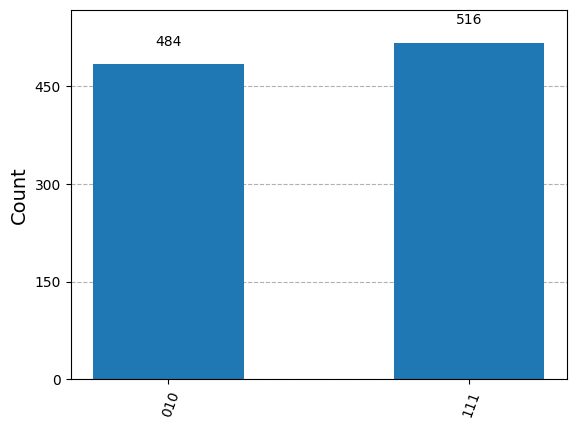

In [ ]:
simulator = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, simulator)

job = simulator.run(transpiled_circuit, shots=1000)
job.result().get_counts()
plot_histogram(job.result().get_counts())

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (1.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j]


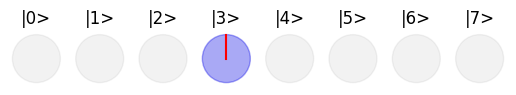

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, 0j, 0j, (1+0j), 0j, 0j, 0j, 0j]


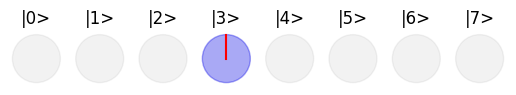

Difference is less than 1e-6: True
qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.7071067811865475, 0.0), (0.7071067811865475, 3.141592653589793), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [0j, 0j, (0.7071067811865475+0j), (-0.7071067811865475+0j), 0j, 0j, 0j, 0j]


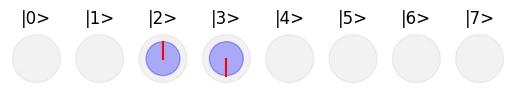

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.7071067811865476, 0.0], [0.7071067811865476, 3.141592653589793], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [0j, 0j, (0.7071067811865476+0j), (-0.7071067811865476+8.659560562354934e-17j), 0j, 0j, 0j, 0j]


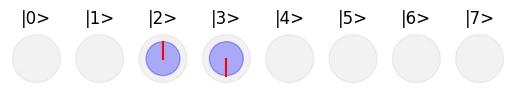

Difference is less than 1e-6: True
qiskit:
Polar: [(0.0, 0.0), (0.0, 0.0), (0.7071067811865475, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.7071067811865475, 3.141592653589793)]
Cartesian: [0j, 0j, (0.7071067811865475+0j), 0j, 0j, 0j, 0j, (-0.7071067811865475+0j)]


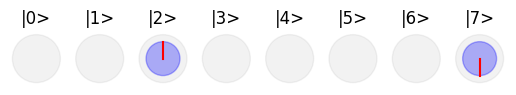

my:
Polar: [[0.0, 0.0], [0.0, 0.0], [0.7071067811865476, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.7071067811865476, 3.141592653589793]]
Cartesian: [0j, 0j, (0.7071067811865476+0j), 0j, 0j, 0j, 0j, (-0.7071067811865476+8.659560562354934e-17j)]


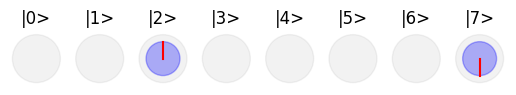

Difference is less than 1e-6: True


In [ ]:
result = round_number(NOT_polar(init_qc, 0, num_qubits))
result = round_number(NOT_polar(result, 1, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

result = round_number(hadamard_polar(result, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

result = round_number(MCX_polar(result, [0,1], 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector2)}")
print(f"Cartesian: {list(statevector2)}")
viz2(Statevector(statevector2))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector2)))<1e-6).all()}")

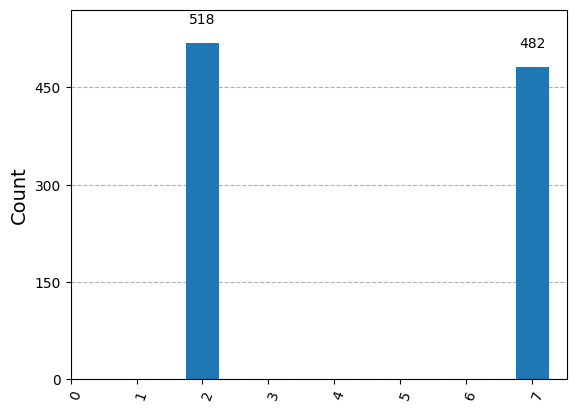

In [ ]:
measure_result = READ_polar_all(result, num_qubits, num_shots=1000)
plot_histogram(measure_result)

## PHASE (correct, normalization added)

In [ ]:
def PHASE_polar(state, target_qubit, phi, num_qubits):
    """
    new_state thetat: [-pi, pi]
    """
    num_states = 2**num_qubits
    new_state = state.copy()

    for i in range(num_states):
        # Check if the target qubit is 0 or 1
          if (i >> target_qubit) & 1 != 0:
              new_theta = state[i][1] + phi
              if new_theta < -np.pi and abs(new_theta+np.pi)>1e-6:
                new_theta += np.pi * 2
              if new_theta > np.pi and abs(new_theta-np.pi)>1e-6:
                new_theta -= np.pi * 2
              new_state[i] = (state[i][0], new_theta)
    for i in range(num_states):
      if new_state[i][1] < -np.pi and abs(new_state[i][1]+np.pi) > 1e-4:
        new_state[i][1] += np.pi * 2
      if new_state[i][1] > np.pi and abs(new_state[i][1]-np.pi) > 1e-4:
        new_state[i][1] -= np.pi * 2
    return new_state


In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(0)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()
statevector_init = Statevector(qc)

qc.p(np.pi/4, 0)
qc.barrier()
statevector1 = Statevector(qc)

qc.draw()

┌───┐ ░ ┌───┐ ░ ┌────────┐ ░ 
q_0: ┤ X ├─░─┤ H ├─░─┤ P(π/4) ├─░─
     └───┘ ░ ├───┤ ░ └────────┘ ░ 
q_1: ──────░─┤ H ├─░────────────░─
           ░ ├───┤ ░            ░ 
q_2: ──────░─┤ H ├─░────────────░─
           ░ └───┘ ░            ░

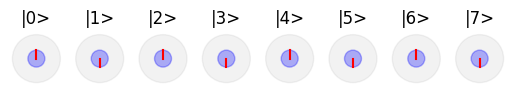

In [ ]:
viz2(statevector_init)

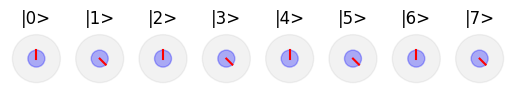

In [ ]:
viz2(statevector1)

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793)]
Cartesian: [(0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j)]


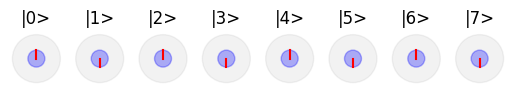

my:
Polar: [[0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793]]
Cartesian: [(0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j)]


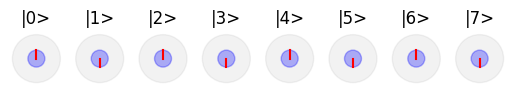

Difference is less than 1e-6: True
qiskit:
Polar: [(0.3535533905932737, 0.0), (0.3535533905932737, -2.356194490192345), (0.3535533905932737, 0.0), (0.3535533905932737, -2.356194490192345), (0.3535533905932737, 0.0), (0.3535533905932737, -2.356194490192345), (0.3535533905932737, 0.0), (0.3535533905932737, -2.356194490192345)]
Cartesian: [(0.3535533905932737+0j), (-0.24999999999999994-0.24999999999999992j), (0.3535533905932737+0j), (-0.24999999999999994-0.24999999999999992j), (0.3535533905932737+0j), (-0.24999999999999994-0.24999999999999992j), (0.3535533905932737+0j), (-0.24999999999999994-0.24999999999999992j)]


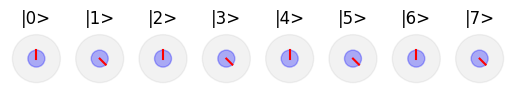

my:
Polar: [[0.3535533905932738, 0.0], [0.3535533905932738, -2.356194490192345], [0.3535533905932738, 0.0], [0.3535533905932738, -2.356194490192345], [0.3535533905932738, 0.0], [0.3535533905932738, -2.356194490192345], [0.3535533905932738, 0.0], [0.3535533905932738, -2.356194490192345]]
Cartesian: [(0.3535533905932738+0j), (-0.25-0.25000000000000006j), (0.3535533905932738+0j), (-0.25-0.25000000000000006j), (0.3535533905932738+0j), (-0.25-0.25000000000000006j), (0.3535533905932738+0j), (-0.25-0.25000000000000006j)]


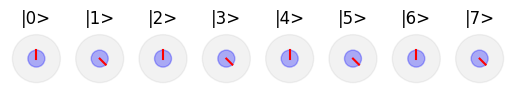

Difference is less than 1e-6: True


In [ ]:
result = round_number(NOT_polar(init_qc, 0, num_qubits))
result = round_number(hadamard_polar(result, 0, num_qubits))
result = round_number(hadamard_polar(result, 1, num_qubits))
result = round_number(hadamard_polar(result, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

result = round_number(PHASE_polar(result, 0, np.pi/4, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

## CPHASE for polar

In [ ]:
def CPHASE_polar(state, control_qubit, target_qubit, phi, num_qubits):
    """
    new_state thetat: [-pi, pi]
    """
    num_states = 2**num_qubits
    new_state = state.copy()

    for i in range(num_states):
        # Check if the target qubit is 0 or 1
        if (i >> control_qubit) & 1 == 1:
            if (i >> target_qubit) & 1 != 0:
                new_theta = state[i][1] + phi
                new_state[i] = [state[i][0], new_theta]
    for i in range(num_states):
      if new_state[i][1] < -np.pi and abs(new_state[i][1]+np.pi) > 1e-4:
        new_state[i][1] += np.pi * 2
      if new_state[i][1] > np.pi and abs(new_state[i][1]-np.pi) > 1e-4:
        new_state[i][1] -= np.pi * 2
    return new_state


In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(0)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()
statevector_init = Statevector(qc)

qc.cp(np.pi/8, 0, 1)
qc.barrier()
statevector1 = Statevector(qc)

qc.draw()

┌───┐ ░ ┌───┐ ░           ░ 
q_0: ┤ X ├─░─┤ H ├─░──■────────░─
     └───┘ ░ ├───┤ ░  │P(π/8)  ░ 
q_1: ──────░─┤ H ├─░──■────────░─
           ░ ├───┤ ░           ░ 
q_2: ──────░─┤ H ├─░───────────░─
           ░ └───┘ ░           ░

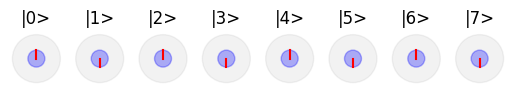

In [ ]:
viz2(statevector_init)

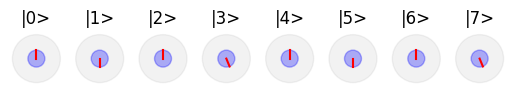

In [ ]:
viz2(statevector1)

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793)]
Cartesian: [(0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.3535533905932737+0j)]


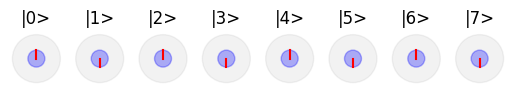

my:
Polar: [[0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793]]
Cartesian: [(0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j)]


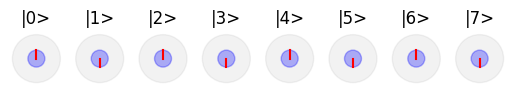

Difference is less than 1e-6: True
qiskit:
Polar: [(0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, -2.748893571891069), (0.3535533905932737, 0.0), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, 0.0), (0.3535533905932737, -2.748893571891069)]
Cartesian: [(0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.32664074121909403-0.13529902503654923j), (0.3535533905932737+0j), (-0.3535533905932737+0j), (0.3535533905932737+0j), (-0.32664074121909403-0.13529902503654923j)]


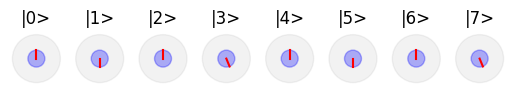

my:
Polar: [[0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, -2.748893571891069], [0.3535533905932738, 0.0], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, 0.0], [0.3535533905932738, -2.748893571891069]]
Cartesian: [(0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.32664074121909414-0.1352990250365493j), (0.3535533905932738+0j), (-0.3535533905932738+4.329780281177467e-17j), (0.3535533905932738+0j), (-0.32664074121909414-0.1352990250365493j)]


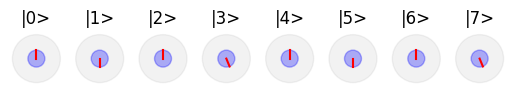

Difference is less than 1e-6: True


In [ ]:
result = round_number(NOT_polar(init_qc, 0, num_qubits))
result = round_number(hadamard_polar(result, 0, num_qubits))
result = round_number(hadamard_polar(result, 1, num_qubits))
result = round_number(hadamard_polar(result, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

result = round_number(CPHASE_polar(result, 0, 1, np.pi/8, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

## SWAP

In [ ]:
def SWAP_polar(state, target_qubit1, target_qubit2, num_qubits):
    num_states = 2**num_qubits
    new_state = state.copy()

    new_state = CNOT_polar(new_state, target_qubit1, target_qubit2, num_qubits)
    new_state = CNOT_polar(new_state, target_qubit2, target_qubit1, num_qubits)
    new_state = CNOT_polar(new_state, target_qubit1, target_qubit2, num_qubits)

    return new_state

In [ ]:
(4 >> 0) & 1 == 0

True

In [ ]:
(4 >> 2) & 1 == 1

True

In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(0)
qc.barrier()

qc.h(0)
# qc.h(1)
# qc.h(2)
qc.barrier()
statevector_init = Statevector(qc)

qc.swap(0, 2)
qc.barrier()
statevector1 = Statevector(qc)

qc.measure_all()
qc.draw()

┌───┐ ░ ┌───┐ ░     ░  ░ ┌─┐      
   q_0: ┤ X ├─░─┤ H ├─░──X──░──░─┤M├──────
        └───┘ ░ └───┘ ░  │  ░  ░ └╥┘┌─┐   
   q_1: ──────░───────░──┼──░──░──╫─┤M├───
              ░       ░  │  ░  ░  ║ └╥┘┌─┐
   q_2: ──────░───────░──X──░──░──╫──╫─┤M├
              ░       ░     ░  ░  ║  ║ └╥┘
meas: 3/══════════════════════════╩══╩══╩═
                                  0  1  2

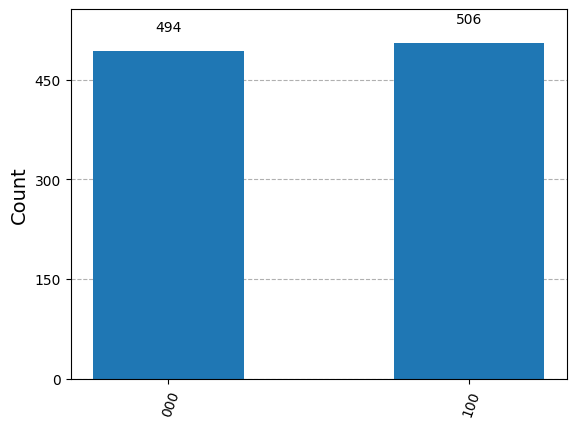

In [ ]:
simulator = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, simulator)

job = simulator.run(transpiled_circuit, shots=1000)
job.result().get_counts()
plot_histogram(job.result().get_counts())

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.7071067811865475, 0.0), (0.7071067811865475, 3.141592653589793), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(0.7071067811865475+0j), (-0.7071067811865475+0j), 0j, 0j, 0j, 0j, 0j, 0j]


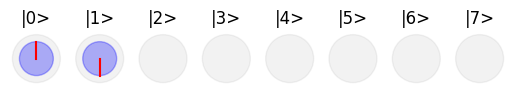

my:
Polar: [[0.7071067811865476, 0.0], [0.7071067811865476, 3.141592653589793], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [(0.7071067811865476+0j), (-0.7071067811865476+8.659560562354934e-17j), 0j, 0j, 0j, 0j, 0j, 0j]


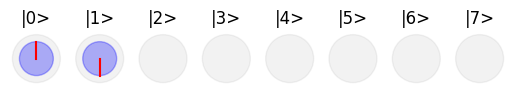

Difference is less than 1e-6: True
qiskit:
Polar: [(0.7071067811865475, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.7071067811865475, 3.141592653589793), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]
Cartesian: [(0.7071067811865475+0j), 0j, 0j, 0j, (-0.7071067811865475+0j), 0j, 0j, 0j]


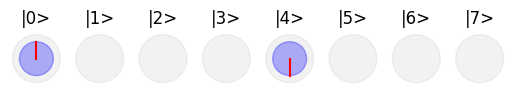

my:
Polar: [[0.7071067811865476, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.7071067811865476, 3.141592653589793], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Cartesian: [(0.7071067811865476+0j), 0j, 0j, 0j, (-0.7071067811865476+8.659560562354934e-17j), 0j, 0j, 0j]


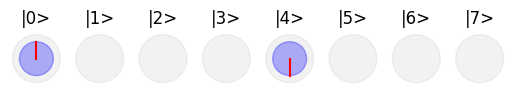

Difference is less than 1e-6: True


In [ ]:
result = round_number(NOT_polar(init_qc, 0, num_qubits))
result = round_number(hadamard_polar(result, 0, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

result = round_number(SWAP_polar(result, 0, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector1)}")
print(f"Cartesian: {list(statevector1)}")
viz2(Statevector(statevector1))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector1)))<1e-6).all()}")

## 3-qubits QFT

In [ ]:
num_qubits = 3
qc = QuantumCircuit(num_qubits)

qc.x(0)
qc.barrier()

qc.append(QFT(num_qubits),[0,1,2])
qc.barrier()
statevector_init = Statevector(qc)

qc.measure_all()
# qc.draw()
qc.decompose(reps=2).draw(fold=-1)

┌──────────┐ ░                                      ┌───┐    ░  ░ ┌─┐      
   q_0: ┤ U(π,0,π) ├─░─────────────────────■────────■───────┤ H ├─X──░──░─┤M├──────
        └──────────┘ ░               ┌───┐ │        │P(π/2) └───┘ │  ░  ░ └╥┘┌─┐   
   q_1: ─────────────░───────■───────┤ H ├─┼────────■─────────────┼──░──░──╫─┤M├───
                     ░ ┌───┐ │P(π/2) └───┘ │P(π/4)                │  ░  ░  ║ └╥┘┌─┐
   q_2: ─────────────░─┤ H ├─■─────────────■──────────────────────X──░──░──╫──╫─┤M├
                     ░ └───┘                                         ░  ░  ║  ║ └╥┘
meas: 3/═══════════════════════════════════════════════════════════════════╩══╩══╩═
                                                                           0  1  2

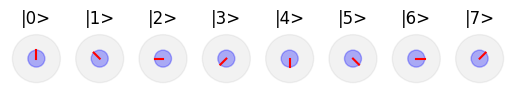

In [ ]:
viz2(statevector_init)

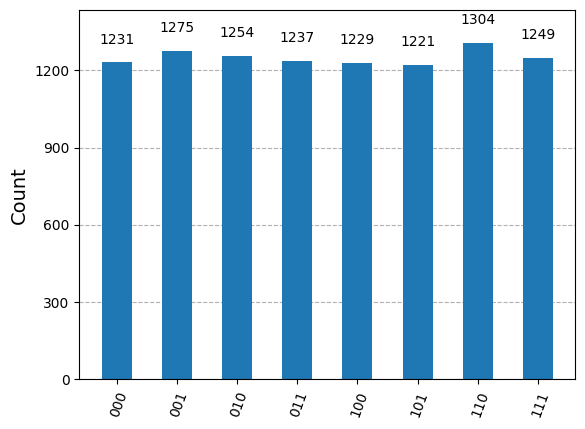

In [ ]:
simulator = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, simulator)

job = simulator.run(transpiled_circuit, shots=10000)
job.result().get_counts()
plot_histogram(job.result().get_counts())

In [ ]:
num_qubits = 3
init_qc = [(1.0 if i == 0 else 0.0, 0.0) for i in range(2**num_qubits)]

qiskit:
Polar: [(0.3535533905932737, 0.0), (0.3535533905932737, 0.7853981633974483), (0.3535533905932737, 1.5707963267948966), (0.3535533905932737, 2.356194490192345), (0.3535533905932737, 3.141592653589793), (0.3535533905932737, -2.356194490192345), (0.3535533905932737, -1.5707963267948968), (0.3535533905932737, -0.7853981633974484)]
Cartesian: [(0.3535533905932737+0j), (0.24999999999999994+0.24999999999999992j), (2.1648901405887326e-17+0.3535533905932737j), (-0.24999999999999992+0.24999999999999994j), (-0.3535533905932737+0j), (-0.24999999999999994-0.24999999999999992j), (-2.1648901405887326e-17-0.3535533905932737j), (0.24999999999999992-0.24999999999999994j)]


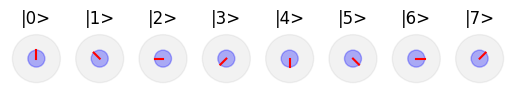

my:
Polar: [[0.3535533905932738, 0.0], [0.3535533905932738, 0.7853981633974483], [0.3535533905932738, 1.5707963267948966], [0.3535533905932738, 2.356194490192345], [0.3535533905932738, 3.141592653589793], [0.3535533905932738, -2.356194490192345], [0.3535533905932738, -1.5707963267948966], [0.3535533905932738, -0.7853981633974483]]
Cartesian: [(0.3535533905932738+0j), (0.25000000000000006+0.25j), (2.1648901405887335e-17+0.3535533905932738j), (-0.25+0.25000000000000006j), (-0.3535533905932738+4.329780281177467e-17j), (-0.25-0.25000000000000006j), (2.1648901405887335e-17-0.3535533905932738j), (0.25000000000000006-0.25j)]


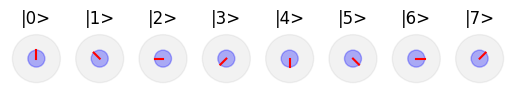

Difference is less than 1e-6: True


In [ ]:
# initialize
result = round_number(NOT_polar(init_qc, 0, num_qubits))

# QFT
result = round_number(hadamard_polar(result, 2, num_qubits))
result = round_number(CPHASE_polar(result, 1, 2, np.pi/2, num_qubits))

result = round_number(hadamard_polar(result, 1, num_qubits))
result = round_number(CPHASE_polar(result, 0, 2, np.pi/4, num_qubits))

result = round_number(CPHASE_polar(result, 0, 1, np.pi/2, num_qubits))
result = round_number(hadamard_polar(result, 0, num_qubits))

result = round_number(SWAP_polar(result, 0, 2, num_qubits))
print(f"qiskit:")
print(f"Polar: {cartesian2polar(statevector_init)}")
print(f"Cartesian: {list(statevector_init)}")
viz2(Statevector(statevector_init))
print(f"my:")
print(f"Polar: {result}")
print(f"Cartesian: {polar2cartesian(result)}")
viz2(polar2cartesian(result))
print(f"Difference is less than 1e-6: {(abs(np.array(result)-np.array(cartesian2polar(statevector_init)))<1e-6).all()}")

# Experiment with k-qubits QFT

In [ ]:
def QFT_polar(circuit: PolarQuantumCircuit, num_qubits: int):
    """
    Implements the Quantum Fourier Transform on the first `num_qubits` of the given PolarQuantumCircuit.
    """
    for i in reversed(range(num_qubits)):
        circuit.hadamard_polar(i)

        for j in reversed(range(i)):
            phi = np.pi / (2 ** (i - j))
            circuit.CPHASE_polar(j, i, phi)

    for i in range(num_qubits // 2):
        circuit.SWAP_polar(i, num_qubits - i - 1)

## simulation time comparison

In [ ]:
num_qubits_list = range(4,11)
num_shot = 1000
times = []
for nq in num_qubits_list:
  # QiSkit Simulation
  qc = QuantumCircuit(nq)
  qc.x(0)
  qc.barrier()

  start_time_qiski = time.time()
  qc.append(QFT(nq),range(nq))
  qc.barrier()
  qc.measure_all()
  simulator = Aer.get_backend('qasm_simulator')
  transpiled_circuit = transpile(qc, simulator)
  job = simulator.run(transpiled_circuit, shots=num_shot)
  result_qiskit = job.result()
  elapsed_time_qiski = time.time() - start_time_qiski

  # Polar Simulation
  circuit = PolarQuantumCircuit(nq)
  circuit.NOT_polar(0)

  start_time_polar = time.time()
  QFT_polar(circuit, nq)
  circuit.simulation(num_shots=num_shot)
  elapsed_time_polar = time.time() - start_time_polar
  times.append([elapsed_time_qiski, elapsed_time_polar])

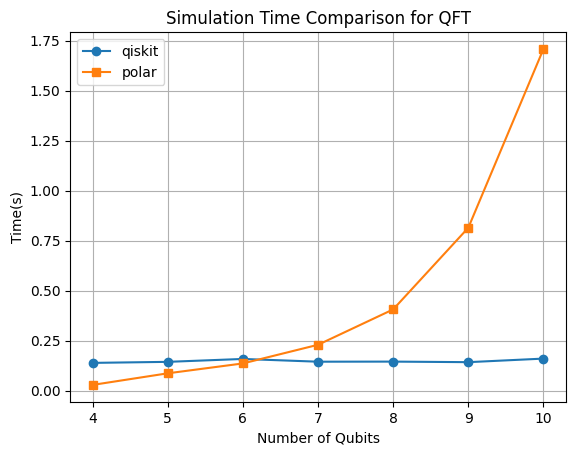

In [ ]:
qiski_times = [t[0] for t in times]  # qiski times
polar_times = [t[1] for t in times]  # polar times

plt.plot(num_qubits_list, qiski_times, label="qiskit", marker='o')
plt.plot(num_qubits_list, polar_times, label="polar", marker='s')

plt.xlabel("Number of Qubits")
plt.ylabel("Time(s)")
plt.title("Simulation Time Comparison for QFT")
plt.legend()
plt.grid(True)
plt.show()

## quantum states (r, theta) difference

In [ ]:
num_qubits_list = range(4,11)
num_shot = 1000
diff_r = []
diff_theta = []

for nq in num_qubits_list:
  # QiSkit Simulation
  qc = QuantumCircuit(nq)
  qc.x(0)
  qc.barrier()

  qc.append(QFT(nq),range(nq))
  qc.barrier()
  statevector_qiski_complex = Statevector(qc)
  statevector_qiski_polar = PolarQuantumCircuit.cartesian2polar(statevector_qiski_complex)
  r_qiski = [i[0] for i in statevector_qiski_polar]
  theta_qiski = [i[1] for i in statevector_qiski_polar]

  # Polar Simulation
  circuit = PolarQuantumCircuit(nq)
  circuit.NOT_polar(0)
  QFT_polar(circuit, nq)
  statevector_polar = circuit.get_state()
  r_polar = [i[0] for i in statevector_polar]
  theta_polar = [i[1] for i in statevector_polar]

  diff_r.append(np.sum(abs(np.array(r_qiski) - np.array(r_polar))))
  diff_theta.append(np.sum(abs(np.array(theta_qiski) - np.array(theta_polar))))

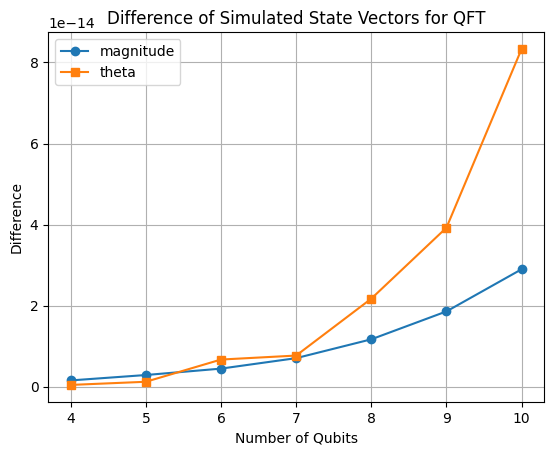

In [ ]:
plt.plot(num_qubits_list, diff_r, label="magnitude", marker='o')
plt.plot(num_qubits_list, diff_theta, label="theta", marker='s')

plt.xlabel("Number of Qubits")
plt.ylabel("Difference")
plt.title("Difference of Simulated State Vectors for QFT")
plt.legend()
plt.grid(True)
plt.show()

# Experiment with k-qubits Grover's

## polar Grover

In [ ]:
def diffusion_polar(circuit: PolarQuantumCircuit, num_qubits: int):
    """
    diffuser creator
    """
    for qubit in range(num_qubits):
        circuit.hadamard_polar(qubit)
    for qubit in range(num_qubits):
        circuit.NOT_polar(qubit)
    circuit.MCPHASE_polar(list(range(num_qubits - 1)), num_qubits - 1)
    for qubit in range(num_qubits):
        circuit.NOT_polar(qubit)
    for qubit in range(num_qubits):
        circuit.hadamard_polar(qubit)

def oracle_polar(circuit: PolarQuantumCircuit, target_positions):
    """
    Oracle creator, encode the key and flip the phase of the target positions.
    """
    if isinstance(target_positions, int):
      target_positions = [target_positions]

    for target_pos in target_positions:
      binary_state = bin(target_pos)[2:].zfill(circuit._num_qubits)

      for i, qubit in enumerate(reversed(binary_state)):
        if qubit == '0':
          circuit.NOT_polar(i)
      circuit.MCPHASE_polar(list(range(circuit._num_qubits - 1)), circuit._num_qubits - 1)
      for i, qubit in enumerate(reversed(binary_state)):
        if qubit == '0':
          circuit.NOT_polar(i)

def Grover_polar(circuit: PolarQuantumCircuit, num_qubits: int, target_positions, iterations: int):
    """
    Implement Grover's algorithm with oracle and diffuser.
    """
    # create superposition
    for qubit in range(num_qubits):
        circuit.hadamard_polar(qubit)

    # Grover iterations
    for _ in range(iterations):
        oracle_polar(circuit, target_positions)
        diffusion_polar(circuit, num_qubits)

{'24': 146, '15': 129, '3': 134, '1': 143, '27': 149, '7': 149, '6': 159, '21': 135, '28': 140, '13': 151, '8': 144, '0': 129, '17': 146, '9': 142, '30': 138, '5': 2902, '20': 128, '2': 131, '14': 147, '23': 140, '10': 141, '25': 129, '19': 150, '26': 137, '18': 161, '16': 156, '22': 133, '12': 2853, '31': 143, '4': 147, '29': 137, '11': 131}


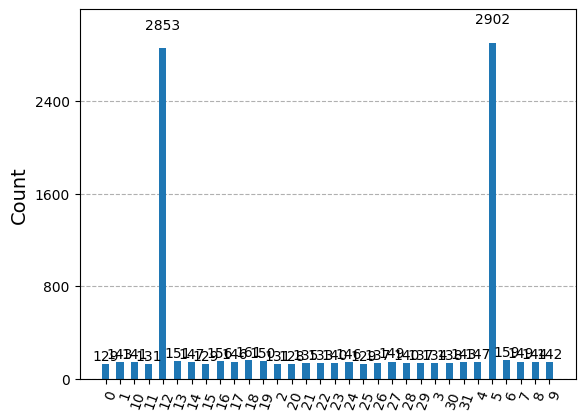

In [ ]:
num_qubits = 5
circuit = PolarQuantumCircuit(num_qubits)

target_pos = [5, 12]
# iterations = 1
iterations = int(np.floor((np.pi * np.sqrt(2 ** num_qubits))/ 4))

Grover_polar(circuit, num_qubits, target_pos, iterations)

result = circuit.simulation(num_shots=10000)
# print(result)
plot_histogram(result)

## QiSkit Grover

In [ ]:
def diffusion_qiskit(num_qubits):
    qcDiffuser = QuantumCircuit(num_qubits, name='Diffuser')

    qcDiffuser.h(range(num_qubits))
    qcDiffuser.x(range(num_qubits))
    qcDiffuser.mcp(np.pi, list(range(num_qubits - 1)), num_qubits - 1)
    qcDiffuser.x(range(num_qubits))
    qcDiffuser.h(range(num_qubits))
    qcDiffuser.to_gate()
    return qcDiffuser

def oracle_qiskit(target_positions, num_qubits: int):
    qcOracle = QuantumCircuit(num_qubits, name='Oracle')

    if isinstance(target_positions, int):
      target_positions = [target_positions]
    for target_pos in target_positions:
      binary_state = bin(target_pos)[2:].zfill(num_qubits)

      for i, qubit in enumerate(reversed(binary_state)):
        if qubit == '0':
          qcOracle.x(i)
      qcOracle.mcp(np.pi, list(range(num_qubits - 1)), num_qubits - 1)
      for i, qubit in enumerate(reversed(binary_state)):
        if qubit == '0':
          qcOracle.x(i)
    qcOracle.to_gate()
    return qcOracle

def Grover_qiski(circuit: QuantumCircuit, num_qubits: int, target_positions, iterations: int):
    qcOracle = oracle_qiskit(target_positions, num_qubits)
    qcDiffusion = diffusion_qiskit(num_qubits)

    circuit.h(range(num_qubits))

    for _ in range(iterations):
        circuit.append(qcOracle, list(range(num_qubits)))
        circuit.append(qcDiffusion, list(range(num_qubits)))

In [ ]:
num_qubits = 5
circuit = QuantumCircuit(num_qubits)

# Define the target state (e.g., |101>)
target_pos = [5, 12]
# iterations = 1
iterations = int(np.floor((np.pi * np.sqrt(2 ** num_qubits))/ 4))

# Run Grover's algorithm
Grover_qiski(circuit, num_qubits, target_pos, iterations)

circuit.measure_all()
circuit.draw()

┌───┐┌─────────┐┌───────────┐┌─────────┐┌───────────┐┌─────────┐»
   q_0: ┤ H ├┤0        ├┤0          ├┤0        ├┤0          ├┤0        ├»
        ├───┤│         ││           ││         ││           ││         │»
   q_1: ┤ H ├┤1        ├┤1          ├┤1        ├┤1          ├┤1        ├»
        ├───┤│         ││           ││         ││           ││         │»
   q_2: ┤ H ├┤2 Oracle ├┤2 Diffuser ├┤2 Oracle ├┤2 Diffuser ├┤2 Oracle ├»
        ├───┤│         ││           ││         ││           ││         │»
   q_3: ┤ H ├┤3        ├┤3          ├┤3        ├┤3          ├┤3        ├»
        ├───┤│         ││           ││         ││           ││         │»
   q_4: ┤ H ├┤4        ├┤4          ├┤4        ├┤4          ├┤4        ├»
        └───┘└─────────┘└───────────┘└─────────┘└───────────┘└─────────┘»
meas: 5/════════════════════════════════════════════════════════════════»
                                                                        »
«        ┌───────────┐┌─────────┐┌───────────┐ ░ ┌─┐            
«   q_0: ┤0          ├┤0        ├┤0          ├─░─┤M├────────────
«        │           ││         ││           │ ░ └╥┘┌─┐         
«   q_1: ┤1          ├┤1        ├┤1          ├─░──╫─┤M├─────────
«        │           ││         ││           │ ░  ║ └╥┘┌─┐      
«   q_2: ┤2 Diffuser ├┤2 Oracle ├┤2 Diffuser ├─░──╫──╫─┤M├──────
«        │           ││         ││           │ ░  ║  ║ └╥┘┌─┐   
«   q_3: ┤3          ├┤3        ├┤3          ├─░──╫──╫──╫─┤M├───
«        │           ││         ││           │ ░  ║  ║  ║ └╥┘┌─┐
«   q_4: ┤4          ├┤4        ├┤4          ├─░──╫──╫──╫──╫─┤M├
«        └───────────┘└─────────┘└───────────┘ ░  ║  ║  ║  ║ └╥┘
«meas: 5/═════════════════════════════════════════╩══╩══╩══╩══╩═
«                                                 0  1  2  3  4

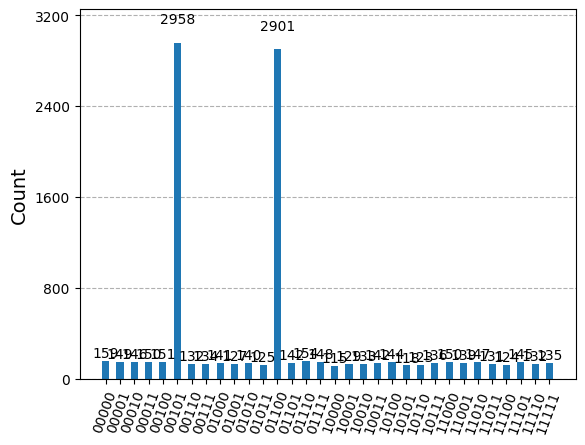

In [ ]:
backend = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=10000)

plot_histogram(job.result().get_counts())

## time comparison

In [ ]:
num_qubits_list = range(4,11)
num_shot = 1000
times = []
for nq in num_qubits_list:
  # print(nq)
  target_pos = [5, 11, 14]
  iterations = int(np.floor((np.pi * np.sqrt(2 ** nq))/ 4))

  # QiSkit Simulation
  qc = QuantumCircuit(nq)

  start_time_qiski = time.time()

  Grover_qiski(qc, nq, target_pos, iterations)
  qc.barrier()
  qc.measure_all()
  simulator = Aer.get_backend('qasm_simulator')
  transpiled_circuit = transpile(qc, simulator)
  job = simulator.run(transpiled_circuit, shots=num_shot)
  result_qiskit = job.result()

  elapsed_time_qiski = time.time() - start_time_qiski

  # Polar Simulation
  circuit = PolarQuantumCircuit(nq)

  start_time_polar = time.time()
  Grover_polar(circuit, nq, target_pos, iterations)
  circuit.simulation(num_shots=num_shot)
  elapsed_time_polar = time.time() - start_time_polar
  times.append([elapsed_time_qiski, elapsed_time_polar])

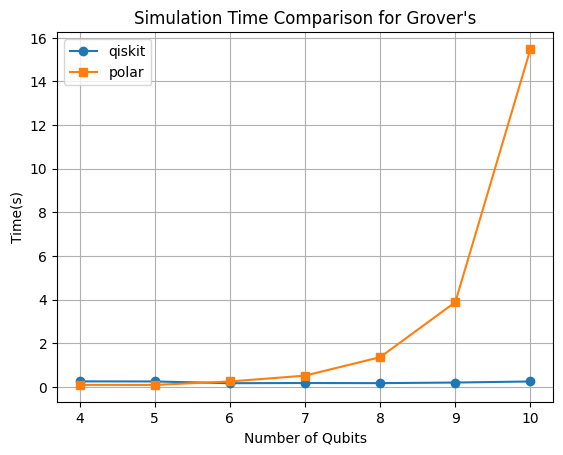

In [ ]:
qiski_times = [t[0] for t in times]  # qiski times
polar_times = [t[1] for t in times]  # polar times

plt.plot(num_qubits_list, qiski_times, label="qiskit", marker='o')
plt.plot(num_qubits_list, polar_times, label="polar", marker='s')

plt.xlabel("Number of Qubits")
plt.ylabel("Time(s)")
plt.title("Simulation Time Comparison for Grover's")
plt.legend()
plt.grid(True)
plt.show()

## quantum states (r, theta) difference

In [ ]:
num_qubits_list = range(4,11)
# num_qubits_list = [3]

diff_r = []
diff_theta = []

for nq in num_qubits_list:
  # print(f"{nq}:######################################")
  target_pos = [5, 11, 14]
  # target_pos = [7, 2]

  iterations = int(np.floor((np.pi * np.sqrt(2 ** nq))/ 4))

  # QiSkit Simulation
  qc = QuantumCircuit(nq)
  Grover_qiski(qc, nq, target_pos, iterations)
  qc.barrier()
  statevector_qiski_complex = Statevector(qc)
  statevector_qiski_polar = PolarQuantumCircuit.cartesian2polar(statevector_qiski_complex)
  # viz2(statevector_qiski_complex)
  # print(statevector_qiski_polar)
  r_qiski = [i[0] for i in statevector_qiski_polar]
  theta_qiski = [i[1] for i in statevector_qiski_polar]

  # Polar Simulation
  circuit = PolarQuantumCircuit(nq)
  Grover_polar(circuit, nq, target_pos, iterations)
  statevector_polar = circuit.get_state()
  # viz2(PolarQuantumCircuit.polar2cartesian(statevector_polar))
  # print(statevector_polar)
  r_polar = [i[0] for i in statevector_polar]
  theta_polar = [i[1] for i in statevector_polar]

  diff_r.append(np.sum(abs(np.array(r_qiski) - np.array(r_polar))))
  diff_theta.append(np.sum(abs(np.array(theta_qiski) - np.array(theta_polar))))

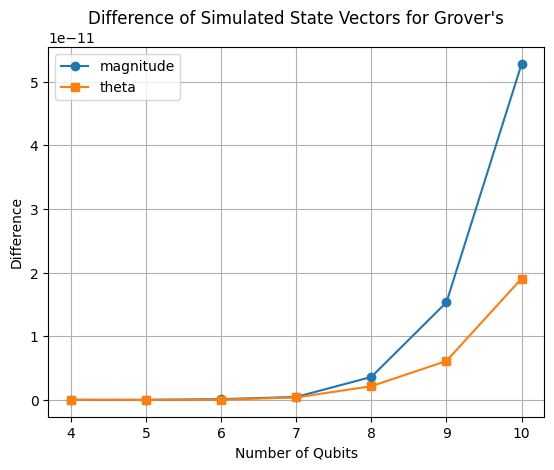

In [ ]:
plt.plot(num_qubits_list, diff_r, label="magnitude", marker='o')
plt.plot(num_qubits_list, diff_theta, label="theta", marker='s')
plt.xlabel("Number of Qubits")
plt.ylabel("Difference")
plt.title("Difference of Simulated State Vectors for Grover's")
plt.legend()
plt.grid(True)
plt.show()

# System info

## hardware

In [ ]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   2
  On-line CPU(s) list:    0,1
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:           6
    Model:                79
    Thread(s) per core:   2
    Core(s) per socket:   1
    Socket(s):            1
    Stepping:             0
    BogoMIPS:             4400.31
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 cl
                          flush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc re
                          p_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3
                           fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand
                           hypervisor lahf_lm abm 3dnowprefetch i

In [ ]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       913Mi       8.6Gi       1.0Mi       3.2Gi        11Gi
Swap:             0B          0B          0B


In [ ]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   33G   76G  31% /
tmpfs            64M     0   64M   0% /dev
shm             5.8G     0  5.8G   0% /dev/shm
/dev/root       2.0G  1.2G  820M  59% /usr/sbin/docker-init
tmpfs           6.4G  308K  6.4G   1% /var/colab
/dev/sda1        50G   34G   17G  68% /etc/hosts
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware


## software

In [ ]:
!uname -a

Linux 5ce5bded174e 6.1.85+ #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024 x86_64 x86_64 x86_64 GNU/Linux


In [ ]:
import numpy as np
import matplotlib
import qiskit
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Qiskit version:", qiskit.__version__)

NumPy version: 1.26.4
Matplotlib version: 3.8.0
Qiskit version: 1.3.1
